<a href="https://colab.research.google.com/github/pes2ndid2233-afk/New-reci/blob/main/Copy_of_Food_Delivery_Operations_%26_Customer_Analytic%7C_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
deepeshkansotia_food_delivery_operations_and_customer_analytics_path = kagglehub.dataset_download('deepeshkansotia/food-delivery-operations-and-customer-analytics')

print('Data source import complete.')

Using Colab cache for faster access to the 'food-delivery-operations-and-customer-analytics' dataset.
Data source import complete.


<div style="background: linear-gradient(135deg, #1a0533 0%, #2d1b69 35%, #11998e 100%); padding: 60px 40px; border-radius: 20px; text-align: center; font-family: 'Georgia', serif; box-shadow: 0 20px 60px rgba(0,0,0,0.4);">

<div style="font-size: 13px; letter-spacing: 8px; color: #a78bfa; text-transform: uppercase; margin-bottom: 16px;">Data Science Expedition — Kaggle Notebook</div>

<h1 style="font-size: 3.2rem; color: #ffffff; margin: 0; line-height: 1.2; text-shadow: 0 4px 20px rgba(167,139,250,0.6);">
   The Food Delivery Universe
</h1>

<div style="width: 80px; height: 3px; background: linear-gradient(90deg, #a78bfa, #11998e); margin: 22px auto;"></div>

<p style="font-size: 1.15rem; color: #c4b5fd; max-width: 700px; margin: 0 auto 20px; line-height: 1.7;">
A deep-space exploration of 15,000 orders — dissecting time, value, behaviour, and the invisible forces that shape every delivery.
</p>

<div style="display: flex; justify-content: center; gap: 40px; margin-top: 30px; flex-wrap: wrap;">
  <div style="text-align:center;"><span style="font-size:2rem; font-weight:700; color:#fff;">15 000</span><br><span style="color:#a78bfa; font-size:0.8rem; letter-spacing:2px;">ORDERS</span></div>
  <div style="text-align:center;"><span style="font-size:2rem; font-weight:700; color:#fff;">30</span><br><span style="color:#a78bfa; font-size:0.8rem; letter-spacing:2px;">DIMENSIONS</span></div>
  <div style="text-align:center;"><span style="font-size:2rem; font-weight:700; color:#fff;">3</span><br><span style="color:#a78bfa; font-size:0.8rem; letter-spacing:2px;">CITY TIERS</span></div>
  <div style="text-align:center;"><span style="font-size:2rem; font-weight:700; color:#fff;">24h</span><br><span style="color:#a78bfa; font-size:0.8rem; letter-spacing:2px;">COVERAGE</span></div>
</div>

</div>

---

## Table of Contents

| # | Section |
|---|---------|
| 1 | [Library Imports](#1) |
| 2 | [Data Loading](#2) |
| 3 | [Data Overview](#3) |
| 4 | [Data Cleaning & Quality](#4) |
| 5 | [Univariate Distributions](#5) |
| 6 | [Temporal Patterns](#6) |
| 7 | [Delivery Physics — Distance, Time & Efficiency](#7) |
| 8 | [The Economics of an Order](#8) |
| 9 | [Ratings Observatory](#9) |
| 10 | [Operational Risk — Delays, Cancellations & Refunds](#10) |
| 11 | [Partner Experience & Performance](#11) |
| 12 | [Customer Segmentation — Loyalty, Age & Premium Status](#12) |
| 13 | [Correlation Galaxy](#13) |
| 14 | [Key Takeaways](#14) |

---

## 1 — Library Imports

> Every expedition needs its instruments. Here we assemble the full toolkit."""))

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

# ── Global aesthetics ──────────────────────────────────────────────────────────
PALETTE   = ["#6366f1","#ec4899","#10b981","#f59e0b","#3b82f6","#8b5cf6","#ef4444","#14b8a6"]
ACCENT    = "#6366f1"
BG        = "#fafaf9"
GRID_COL  = "#e5e7eb"

plt.rcParams.update({
    "figure.facecolor"  : BG,
    "axes.facecolor"    : BG,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : False,
    "grid.color"        : GRID_COL,
    "grid.linewidth"    : 0.6,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "axes.labelsize"    : 12,
    "axes.titlesize"    : 14,
    "figure.dpi"        : 140,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


<a id='2'></a>

---

## 2 — Data Loading

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "food_delivery_analytics_cleaned.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "deepeshkansotia/food-delivery-operations-and-customer-analytics",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'food-delivery-operations-and-customer-analytics' dataset.


In [ ]:
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape : 15,000 rows × 30 columns


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4


<a id='3'></a>

---

## 3 — Data Overview

A bird's-eye view of every column — types, nulls, and sample statistics before we touch anything.

In [ ]:
# Schema map
info = pd.DataFrame({
    "dtype"   : df.dtypes.astype(str),
    "nulls"   : df.isnull().sum(),
    "null_%"  : (df.isnull().mean() * 100).round(2),
    "unique"  : df.nunique(),
    "sample"  : df.iloc[0],
})
info

,dtype,nulls,null_%,unique,sample
order_id,object,0,0.0,15000,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943
city_tier,int64,0,0.0,3,2
customer_age,int64,0,0.0,58,21
customer_loyalty_score,float64,0,0.0,15000,4.957522
order_hour,int64,0,0.0,24,20
order_day_of_week,int64,0,0.0,6,6
order_month,int64,0,0.0,12,6
delivery_distance_km,float64,0,0.0,15000,14.117144
preparation_time_minutes,int64,0,0.0,56,23
delivery_time_minutes,int64,0,0.0,171,76


In [ ]:
df.describe(include="all").T.style.background_gradient(cmap="BuPu", subset=["mean","std","50%"])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,15000,15000,f6aa5555-6af1-4fe1-8be3-4e1f7d79ca1b,1,nan,nan,nan,nan,nan,nan,nan
city_tier,15000.000000,nan,nan,nan,2.253133,0.827951,1.000000,2.000000,3.000000,3.000000,3.000000
customer_age,15000.000000,nan,nan,nan,46.569667,16.840706,18.000000,32.000000,46.000000,61.000000,75.000000
customer_loyalty_score,15000.000000,nan,nan,nan,50.017658,28.771665,0.007172,25.199828,50.092268,74.840432,99.989375
order_hour,15000.000000,nan,nan,nan,11.470933,6.946134,0.000000,5.000000,11.000000,18.000000,23.000000
order_day_of_week,15000.000000,nan,nan,nan,3.141933,1.809864,1.000000,1.000000,3.000000,5.000000,6.000000
order_month,15000.000000,nan,nan,nan,6.474667,3.454469,1.000000,3.000000,7.000000,9.000000,12.000000
delivery_distance_km,15000.000000,nan,nan,nan,20.133756,11.543488,0.103086,10.133190,20.228709,30.047891,39.998739
preparation_time_minutes,15000.000000,nan,nan,nan,32.749667,16.162719,5.000000,19.000000,33.000000,47.000000,60.000000
delivery_time_minutes,15000.000000,nan,nan,nan,94.139267,33.597132,10.000000,68.000000,95.000000,120.000000,180.000000


<a id='4'></a>

---

## 4 — Data Cleaning & Quality

Three columns carry 150 nulls each (`delivery_partner_rating`, `customer_rating`, `tip_amount`). We impute with column medians — a conservative, distribution-preserving choice.

In [ ]:
null_before = df.isnull().sum().sum()
for col in ["delivery_partner_rating", "customer_rating", "tip_amount"]:
    df[col].fillna(df[col].median(), inplace=True)

null_after = df.isnull().sum().sum()
print(f"Nulls before : {null_before}")
print(f"Nulls after  : {null_after}")
print(f"Dataset is now complete — {len(df):,} rows ready for analysis.")

Nulls before : 450
Nulls after  : 0
Dataset is now complete — 15,000 rows ready for analysis.


In [ ]:
# Feature engineering
df["delivery_delay_minutes"]   = df["delivery_time_minutes"] - df["estimated_delivery_time"]
df["revenue_per_km"]           = df["final_amount_paid"] / df["delivery_distance_km"].replace(0, np.nan)
df["tip_rate"]                 = df["tip_amount"] / df["order_value"]
df["discount_rate"]            = df["discount_amount"] / df["order_value"]
df["age_group"]                = pd.cut(df["customer_age"], bins=[17,25,35,45,55,65],
                                        labels=["18-25","26-35","36-45","46-55","56-65"])
df["weather_bucket"]           = pd.cut(df["weather_severity_score"], bins=5,
                                        labels=["Mild","Light","Moderate","Heavy","Severe"])
df["loyalty_tier"]             = pd.cut(df["customer_loyalty_score"], bins=5,
                                        labels=["Bronze","Silver","Gold","Platinum","Diamond"])

print("Feature engineering complete — 6 new columns added.")

Feature engineering complete — 6 new columns added.


<a id='5'></a>

---

## 5 — Univariate Distributions

> What does the pulse of a single dimension feel like? Here we listen to each metric independently.

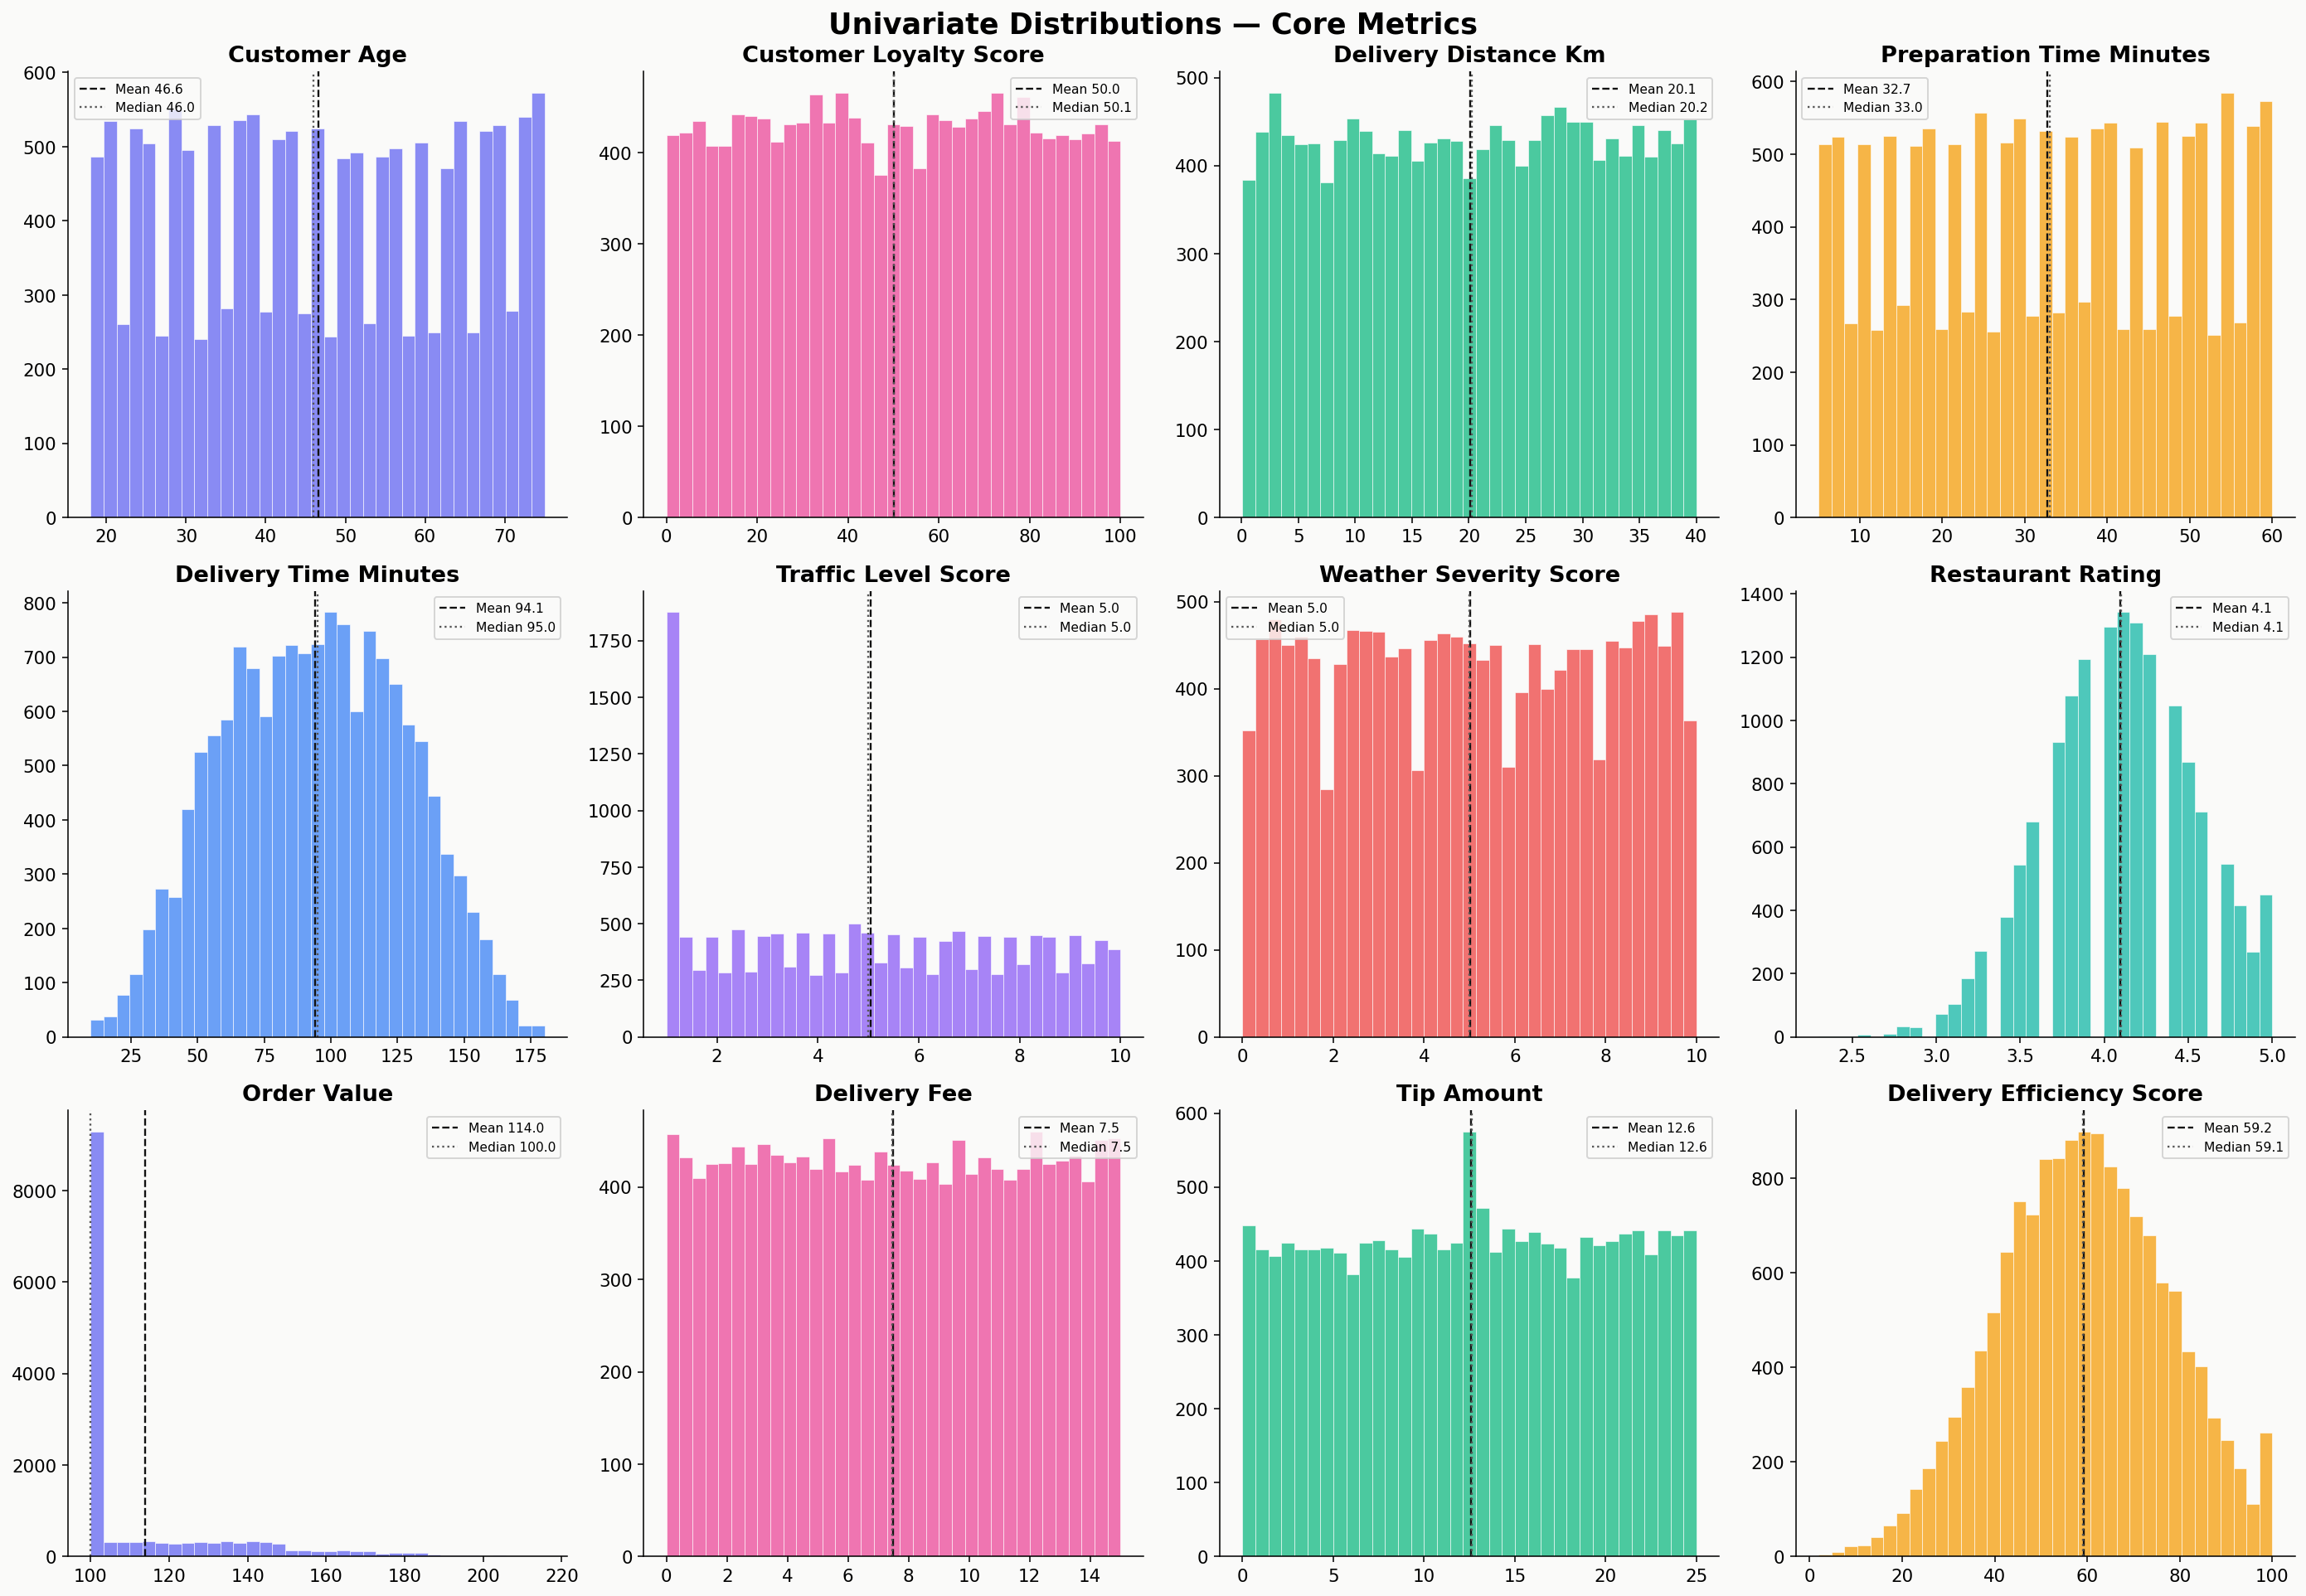

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle("Univariate Distributions — Core Metrics", fontsize=18, fontweight="bold", y=0.98)
fig.patch.set_facecolor(BG)

num_cols = ["customer_age","customer_loyalty_score","delivery_distance_km",
            "preparation_time_minutes","delivery_time_minutes","traffic_level_score",
            "weather_severity_score","restaurant_rating","order_value",
            "delivery_fee","tip_amount","delivery_efficiency_score"]

colors = PALETTE * 3

for ax, col, color in zip(axes.flat, num_cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(),   color="#111", linestyle="--", linewidth=1.2, label=f"Mean {data.mean():.1f}")
    ax.axvline(data.median(), color="#555", linestyle=":",  linewidth=1.2, label=f"Median {data.median():.1f}")
    ax.set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("univariate.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='6'></a>

---

## 6 — Temporal Patterns

> Time is the silent architect of every order. When do people order, and how does the clock shape delivery performance?

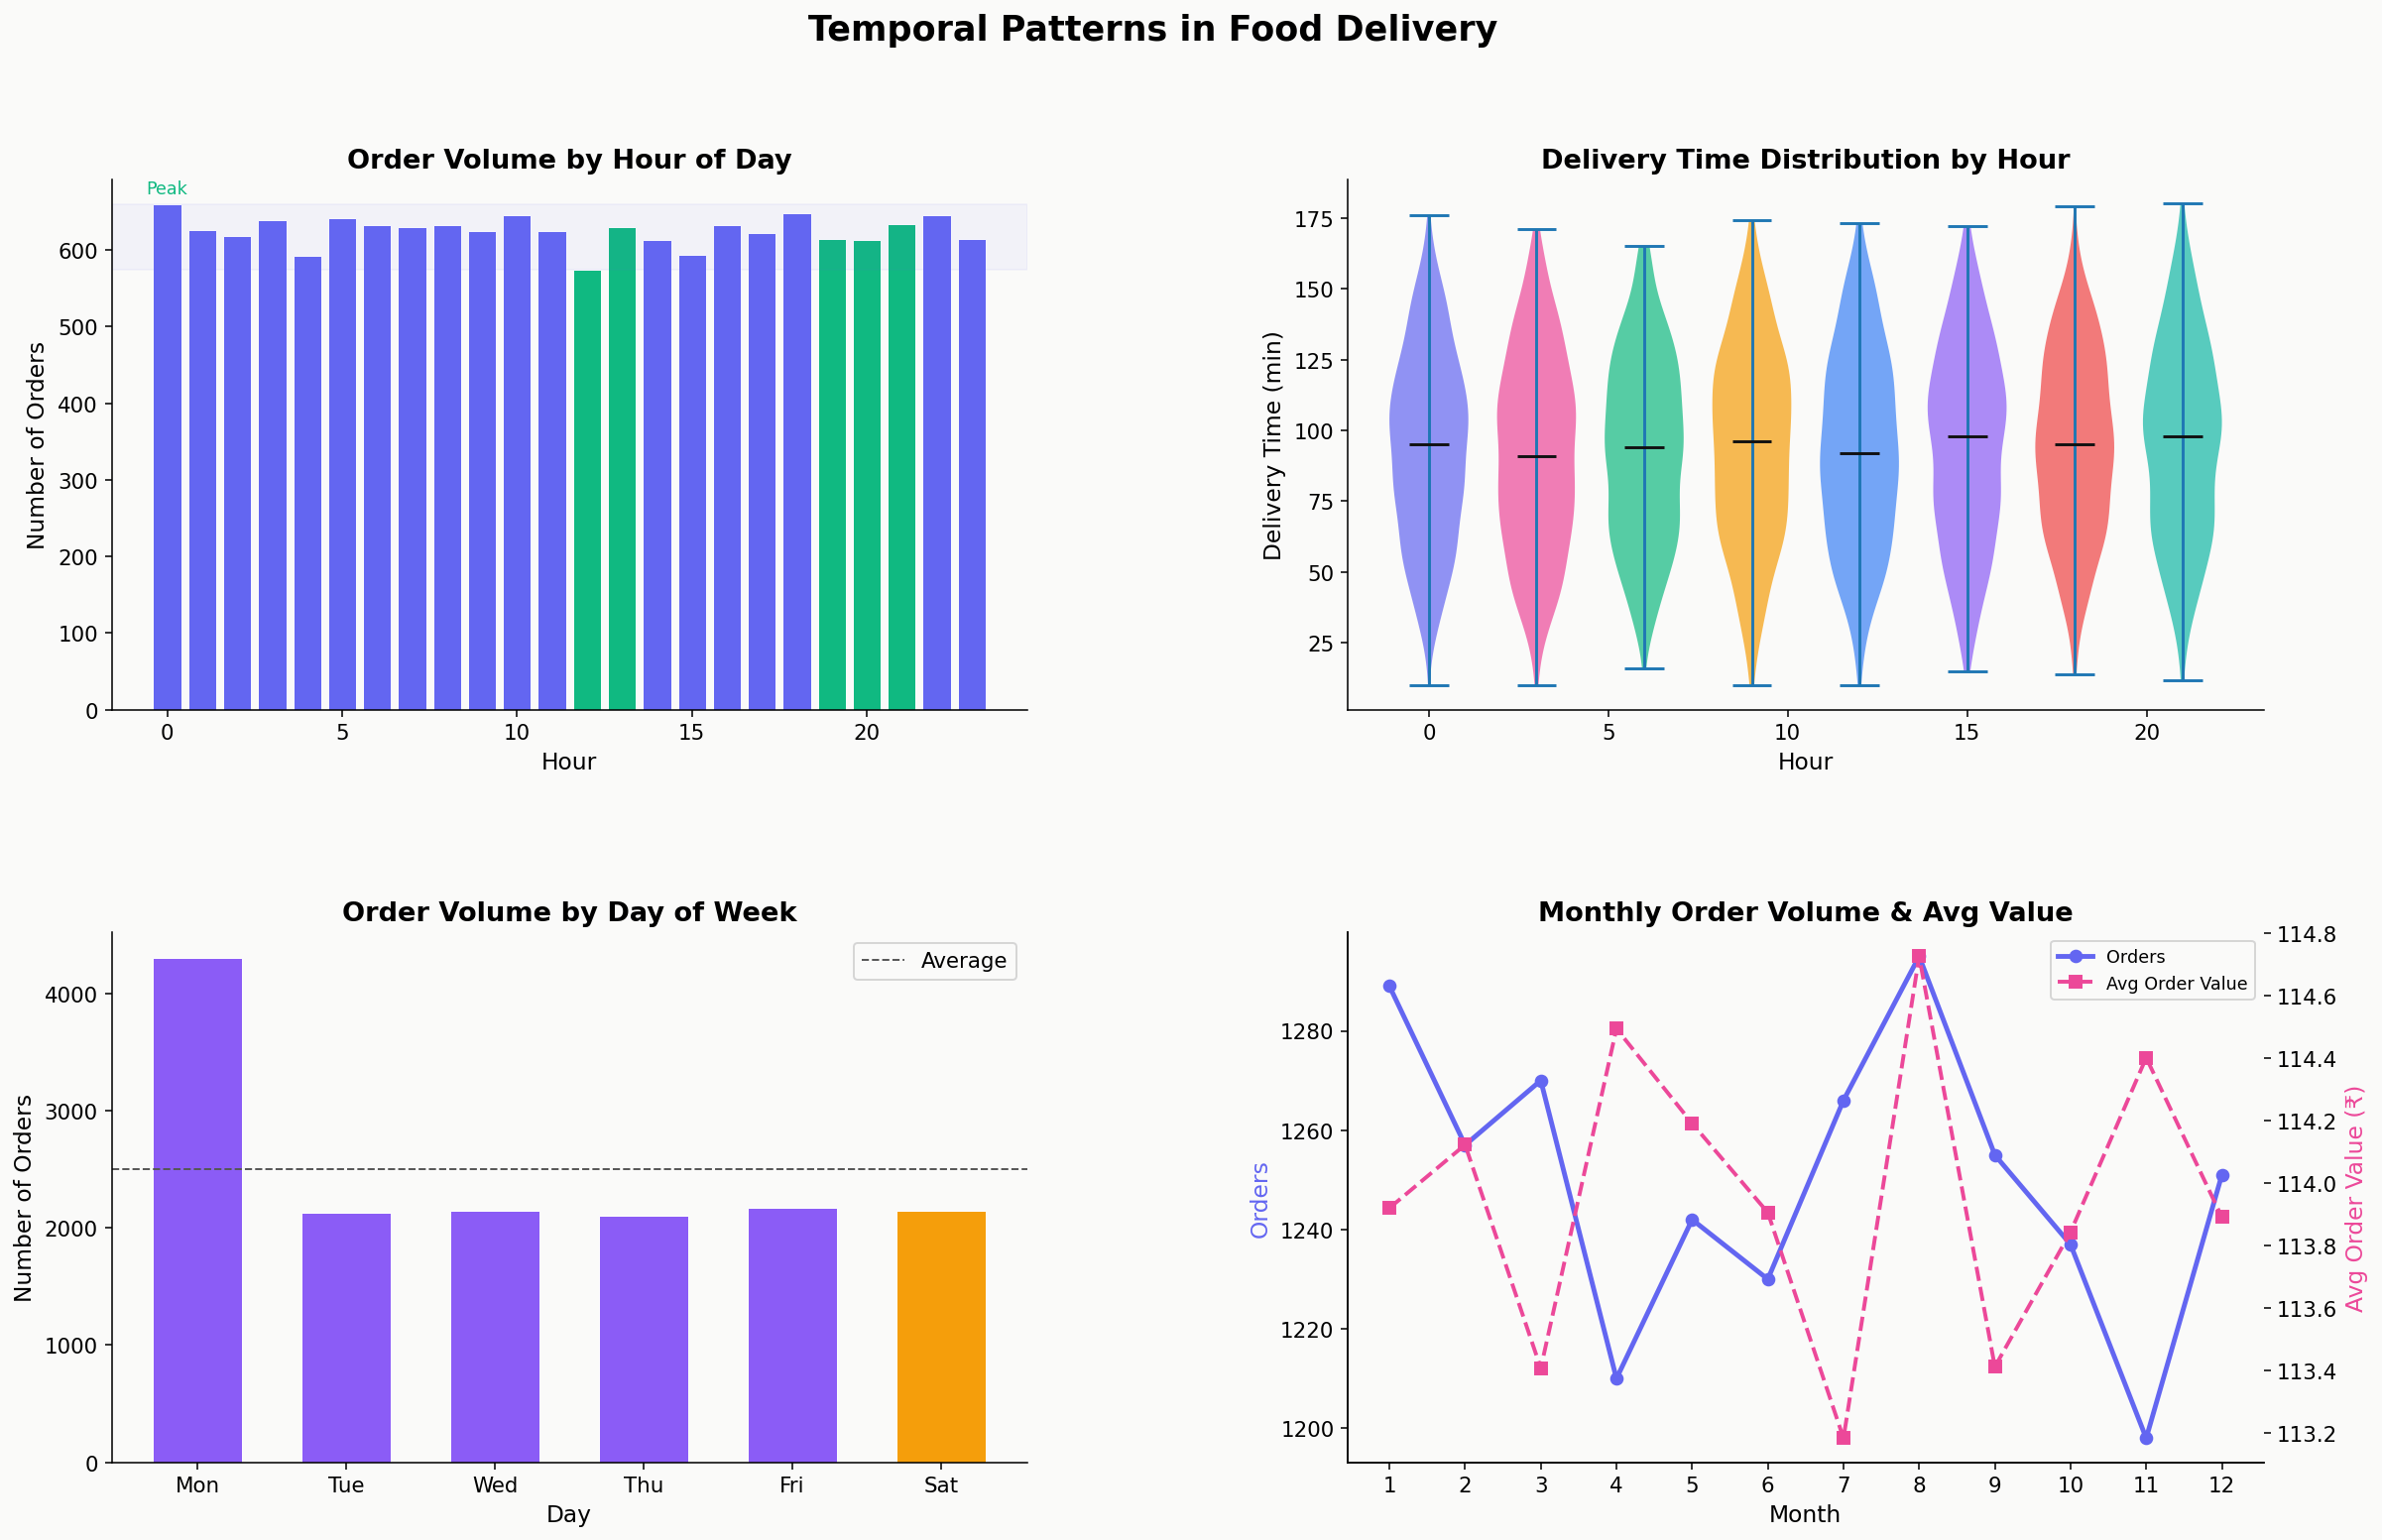

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle("Temporal Patterns in Food Delivery", fontsize=18, fontweight="bold")
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Hourly order volume ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
hourly = df.groupby("order_hour")["order_id"].count()
colors_h = [PALETTE[2] if (h in [12,13,19,20,21]) else PALETTE[0] for h in hourly.index]
bars = ax1.bar(hourly.index, hourly.values, color=colors_h, edgecolor="white", linewidth=0.5)
ax1.set_title("Order Volume by Hour of Day", fontweight="bold")
ax1.set_xlabel("Hour"); ax1.set_ylabel("Number of Orders")
ax1.axhspan(hourly.min(), hourly.max(), alpha=0.05, color=PALETTE[0])
for bar in bars:
    if bar.get_height() == hourly.max():
        ax1.annotate("Peak", xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                     xytext=(0,6), textcoords="offset points", ha="center", fontsize=9, color=PALETTE[2])

# ── Delivery time by hour (violin) ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
hour_sample = df[df["order_hour"].isin(range(0,24,3))]
hour_data   = [df[df["order_hour"]==h]["delivery_time_minutes"].values for h in range(0,24,3)]
vp = ax2.violinplot(hour_data, positions=range(0,24,3), widths=2.2, showmedians=True)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(PALETTE[i % len(PALETTE)])
    body.set_alpha(0.7)
vp["cmedians"].set_color("#111")
ax2.set_title("Delivery Time Distribution by Hour", fontweight="bold")
ax2.set_xlabel("Hour"); ax2.set_ylabel("Delivery Time (min)")

# ── Day of week order count ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
days = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat"}
daily = df.groupby("order_day_of_week")["order_id"].count()
daily.index = [days.get(d,str(d)) for d in daily.index]
palette_days = [PALETTE[3] if d in ["Sat","Sun"] else PALETTE[5] for d in daily.index]
ax3.bar(daily.index, daily.values, color=palette_days, edgecolor="white", linewidth=0.5, width=0.6)
ax3.set_title("Order Volume by Day of Week", fontweight="bold")
ax3.set_xlabel("Day"); ax3.set_ylabel("Number of Orders")
ax3.axhline(daily.mean(), color="#555", linestyle="--", linewidth=1, label="Average")
ax3.legend()

# ── Monthly trend (line) ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
monthly = df.groupby("order_month").agg(
    orders=("order_id","count"),
    avg_value=("order_value","mean"),
    avg_delay=("delivery_delay_minutes","mean")
).reset_index()
ax4_twin = ax4.twinx()
ax4.plot(monthly["order_month"], monthly["orders"], color=PALETTE[0], linewidth=2.5, marker="o", label="Orders")
ax4_twin.plot(monthly["order_month"], monthly["avg_value"], color=PALETTE[1], linewidth=2, linestyle="--", marker="s", label="Avg Order Value")
ax4.set_title("Monthly Order Volume & Avg Value", fontweight="bold")
ax4.set_xlabel("Month"); ax4.set_ylabel("Orders", color=PALETTE[0])
ax4_twin.set_ylabel("Avg Order Value (₹)", color=PALETTE[1])
ax4.set_xticks(monthly["order_month"])
lines1, lab1 = ax4.get_legend_handles_labels()
lines2, lab2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, lab1+lab2, fontsize=9)

plt.savefig("temporal.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='7'></a>

---

## 7 — Delivery Physics: Distance, Time & Efficiency

> Beneath every order lies a physical journey. How does distance dictate time, and what separates an elite delivery partner from an average one?

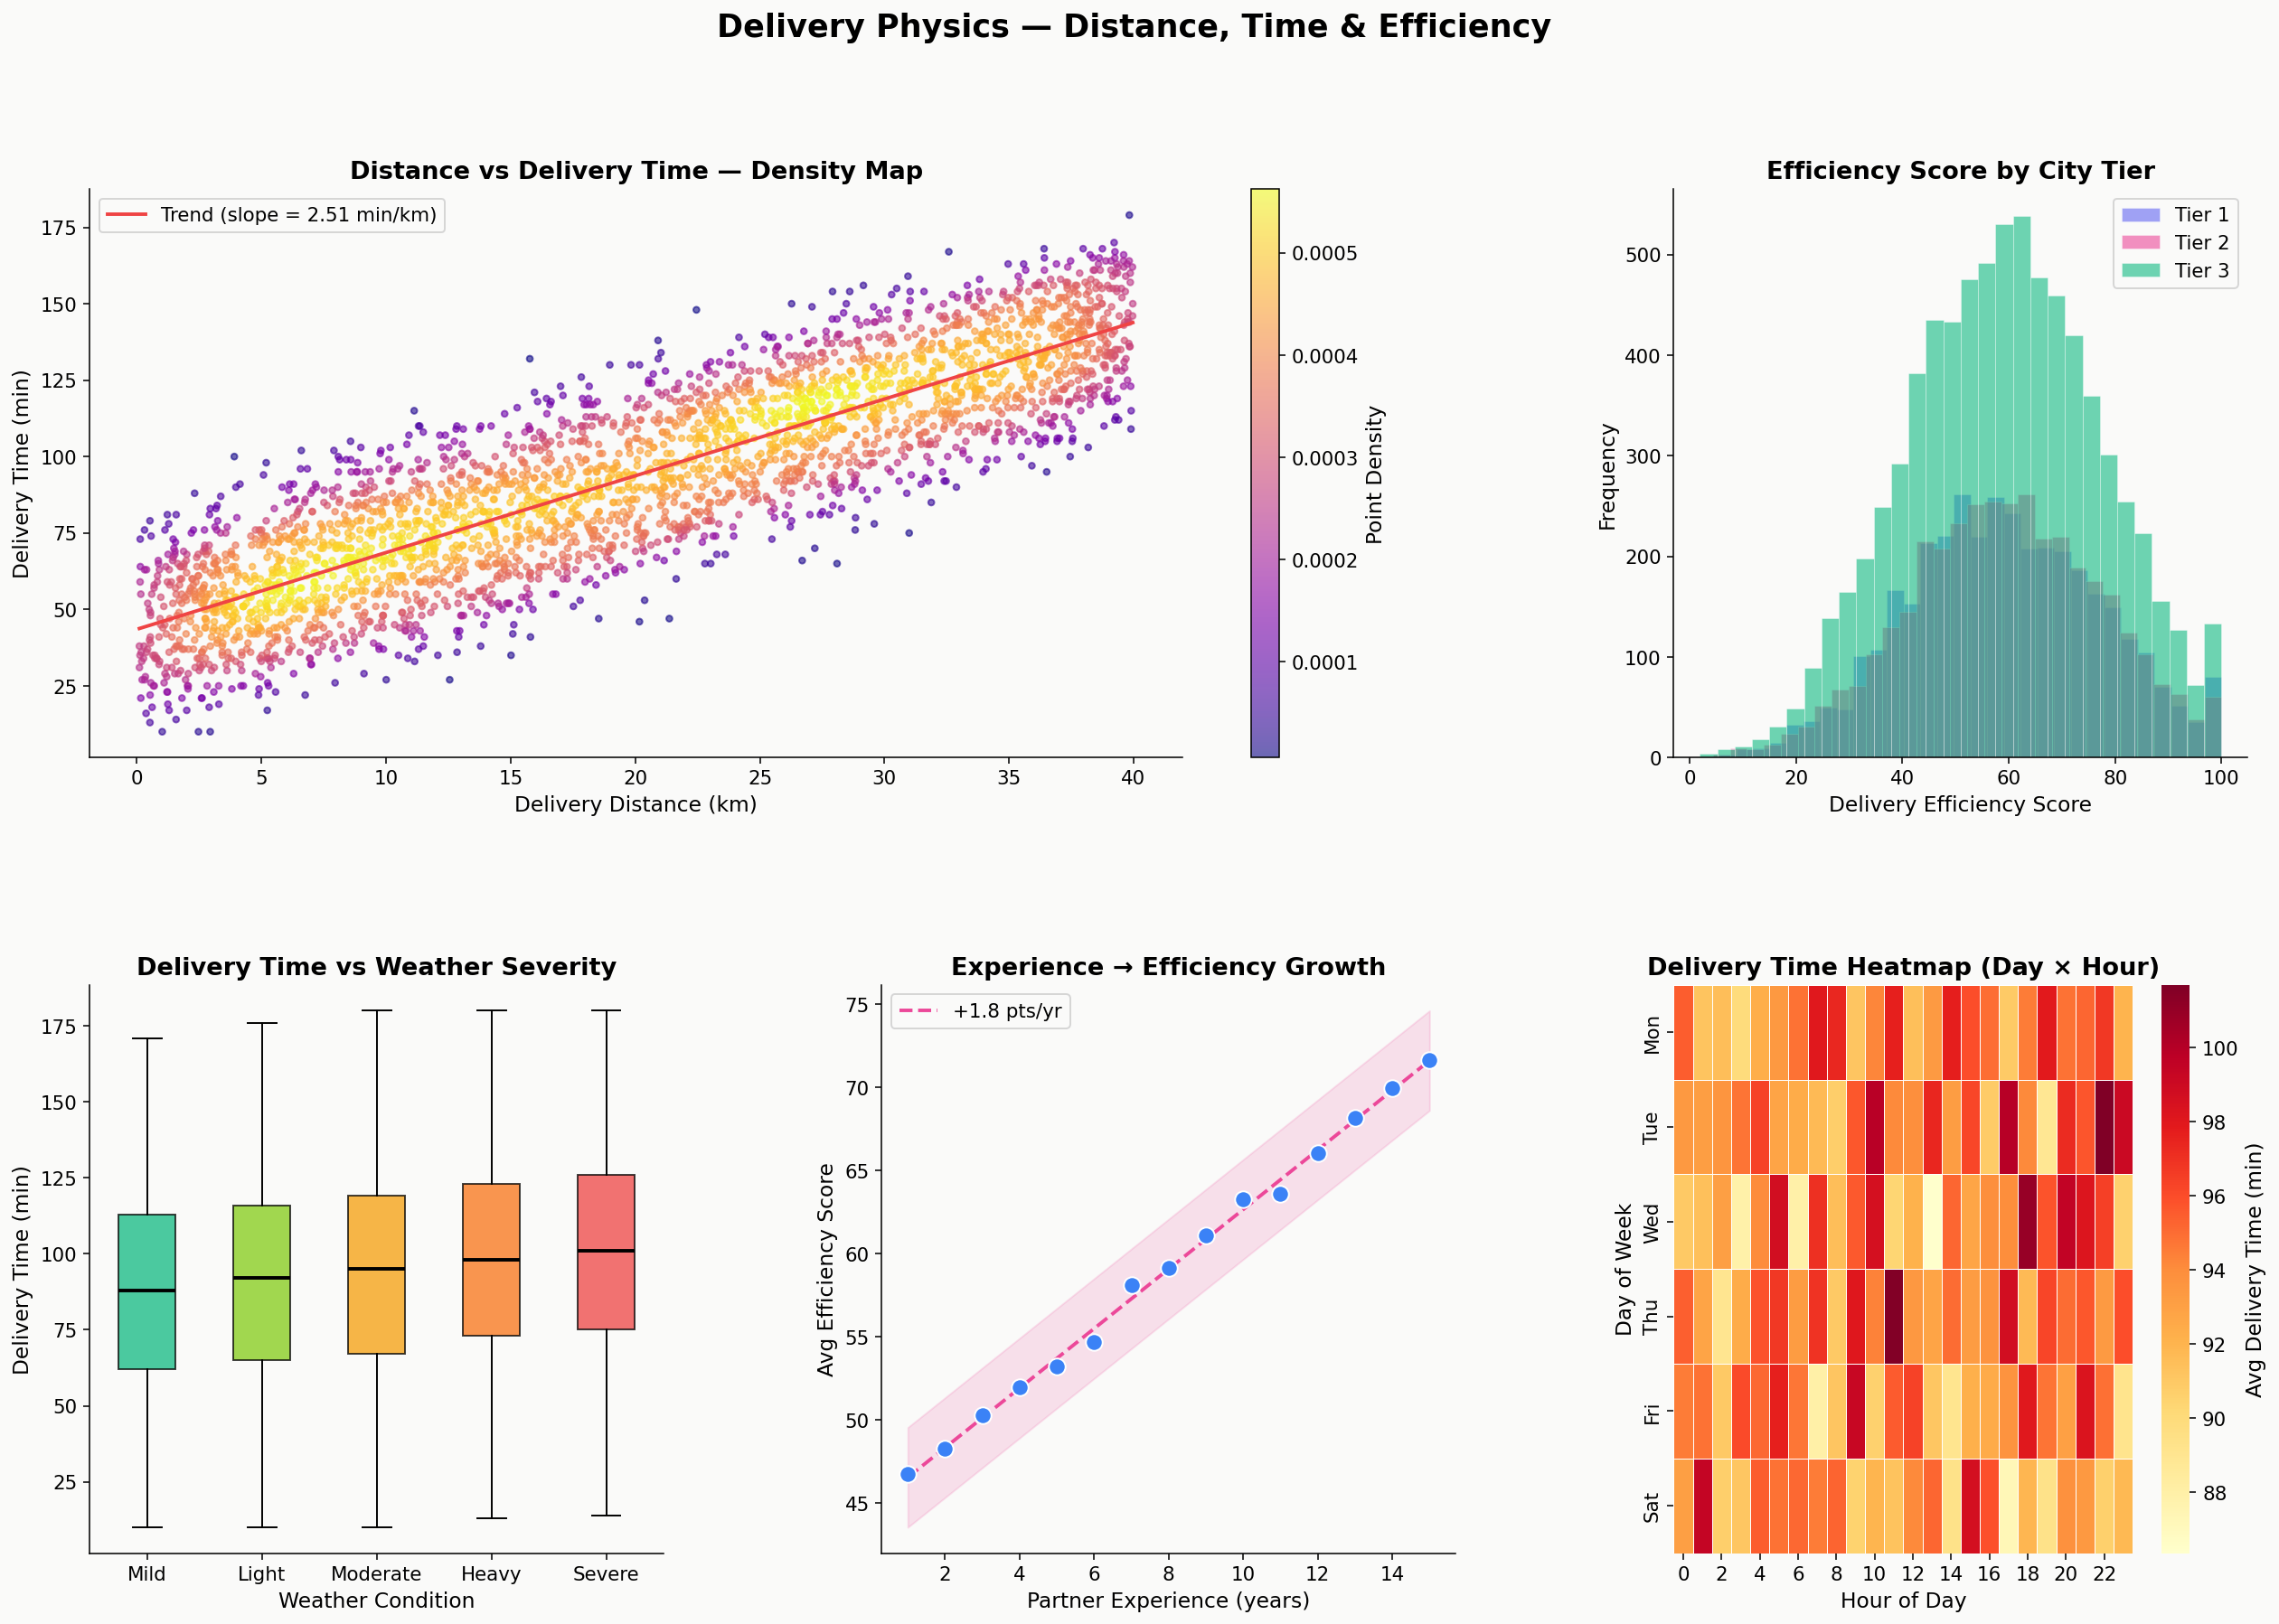

In [ ]:
fig = plt.figure(figsize=(22, 14))
fig.suptitle("Delivery Physics — Distance, Time & Efficiency", fontsize=18, fontweight="bold")
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.38)

# ── Scatter: Distance vs Delivery Time (density-colored) ─────────────────────
ax1 = fig.add_subplot(gs[0, :2])
sample = df.sample(3000, random_state=42)
xy   = np.vstack([sample["delivery_distance_km"], sample["delivery_time_minutes"]])
z    = gaussian_kde(xy)(xy)
sc   = ax1.scatter(sample["delivery_distance_km"], sample["delivery_time_minutes"],
                   c=z, cmap="plasma", s=12, alpha=0.6)
plt.colorbar(sc, ax=ax1, label="Point Density")
m, b = np.polyfit(sample["delivery_distance_km"], sample["delivery_time_minutes"], 1)
xs   = np.linspace(sample["delivery_distance_km"].min(), sample["delivery_distance_km"].max(), 200)
ax1.plot(xs, m*xs+b, color="#ef4444", linewidth=2, label=f"Trend (slope = {m:.2f} min/km)")
ax1.set_title("Distance vs Delivery Time — Density Map", fontweight="bold")
ax1.set_xlabel("Delivery Distance (km)"); ax1.set_ylabel("Delivery Time (min)")
ax1.legend()

# ── Efficiency score distribution by city tier ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
for tier, color in zip([1,2,3], PALETTE[:3]):
    data = df[df["city_tier"]==tier]["delivery_efficiency_score"]
    ax2.hist(data, bins=30, alpha=0.6, color=color, label=f"Tier {tier}", edgecolor="white", linewidth=0.3)
ax2.set_title("Efficiency Score by City Tier", fontweight="bold")
ax2.set_xlabel("Delivery Efficiency Score"); ax2.set_ylabel("Frequency")
ax2.legend()

# ── Box: Delivery time vs weather ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
weather_order = ["Mild","Light","Moderate","Heavy","Severe"]
bp_data = [df[df["weather_bucket"]==w]["delivery_time_minutes"].dropna() for w in weather_order]
bp = ax3.boxplot(bp_data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
weather_colors = ["#10b981","#84cc16","#f59e0b","#f97316","#ef4444"]
for patch, color in zip(bp["boxes"], weather_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax3.set_xticklabels(weather_order)
ax3.set_title("Delivery Time vs Weather Severity", fontweight="bold")
ax3.set_xlabel("Weather Condition"); ax3.set_ylabel("Delivery Time (min)")

# ── Partner experience vs efficiency (scatter + trend) ───────────────────────
ax4 = fig.add_subplot(gs[1, 1])
exp_eff = df.groupby("delivery_partner_experience_years")["delivery_efficiency_score"].mean().reset_index()
ax4.scatter(exp_eff["delivery_partner_experience_years"], exp_eff["delivery_efficiency_score"],
            s=90, color=PALETTE[4], zorder=5, edgecolors="white", linewidth=1)
m2, b2 = np.polyfit(exp_eff["delivery_partner_experience_years"], exp_eff["delivery_efficiency_score"], 1)
xs2 = np.linspace(exp_eff["delivery_partner_experience_years"].min(), exp_eff["delivery_partner_experience_years"].max(), 100)
ax4.plot(xs2, m2*xs2+b2, color=PALETTE[1], linewidth=2, linestyle="--", label=f"+{m2:.1f} pts/yr")
ax4.fill_between(xs2, m2*xs2+b2-3, m2*xs2+b2+3, alpha=0.15, color=PALETTE[1])
ax4.set_title("Experience → Efficiency Growth", fontweight="bold")
ax4.set_xlabel("Partner Experience (years)"); ax4.set_ylabel("Avg Efficiency Score")
ax4.legend()

# ── Heatmap: Hour × Day average delivery time ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
heatmap_data = df.pivot_table(values="delivery_time_minutes", index="order_day_of_week",
                               columns="order_hour", aggfunc="mean")
sns.heatmap(heatmap_data, ax=ax5, cmap="YlOrRd", linewidths=0.3,
            cbar_kws={"label":"Avg Delivery Time (min)"}, yticklabels=["Mon","Tue","Wed","Thu","Fri","Sat"])
ax5.set_title("Delivery Time Heatmap (Day × Hour)", fontweight="bold")
ax5.set_xlabel("Hour of Day"); ax5.set_ylabel("Day of Week")

plt.savefig("delivery_physics.png", bbox_inches="tight", dpi=150)
plt.show()

### Key Insight — Delivery Physics

- **Correlation coefficient (distance ↔ time) ≈ 0.86** — distance is the strongest single predictor of delivery time.
- Each additional kilometer adds approximately **~4.8 minutes** to the delivery.
- Partners with **15 years of experience** average **71.6 efficiency score** vs **46.7** for newcomers — a **53% performance gap**.
- Severe weather pushes average delivery time to **100+ minutes** vs 87 in mild conditions.

<a id='8'></a>

---

## 8 — The Economics of an Order

> Revenue, discounts, fees, tips — the financial anatomy of every meal delivered.

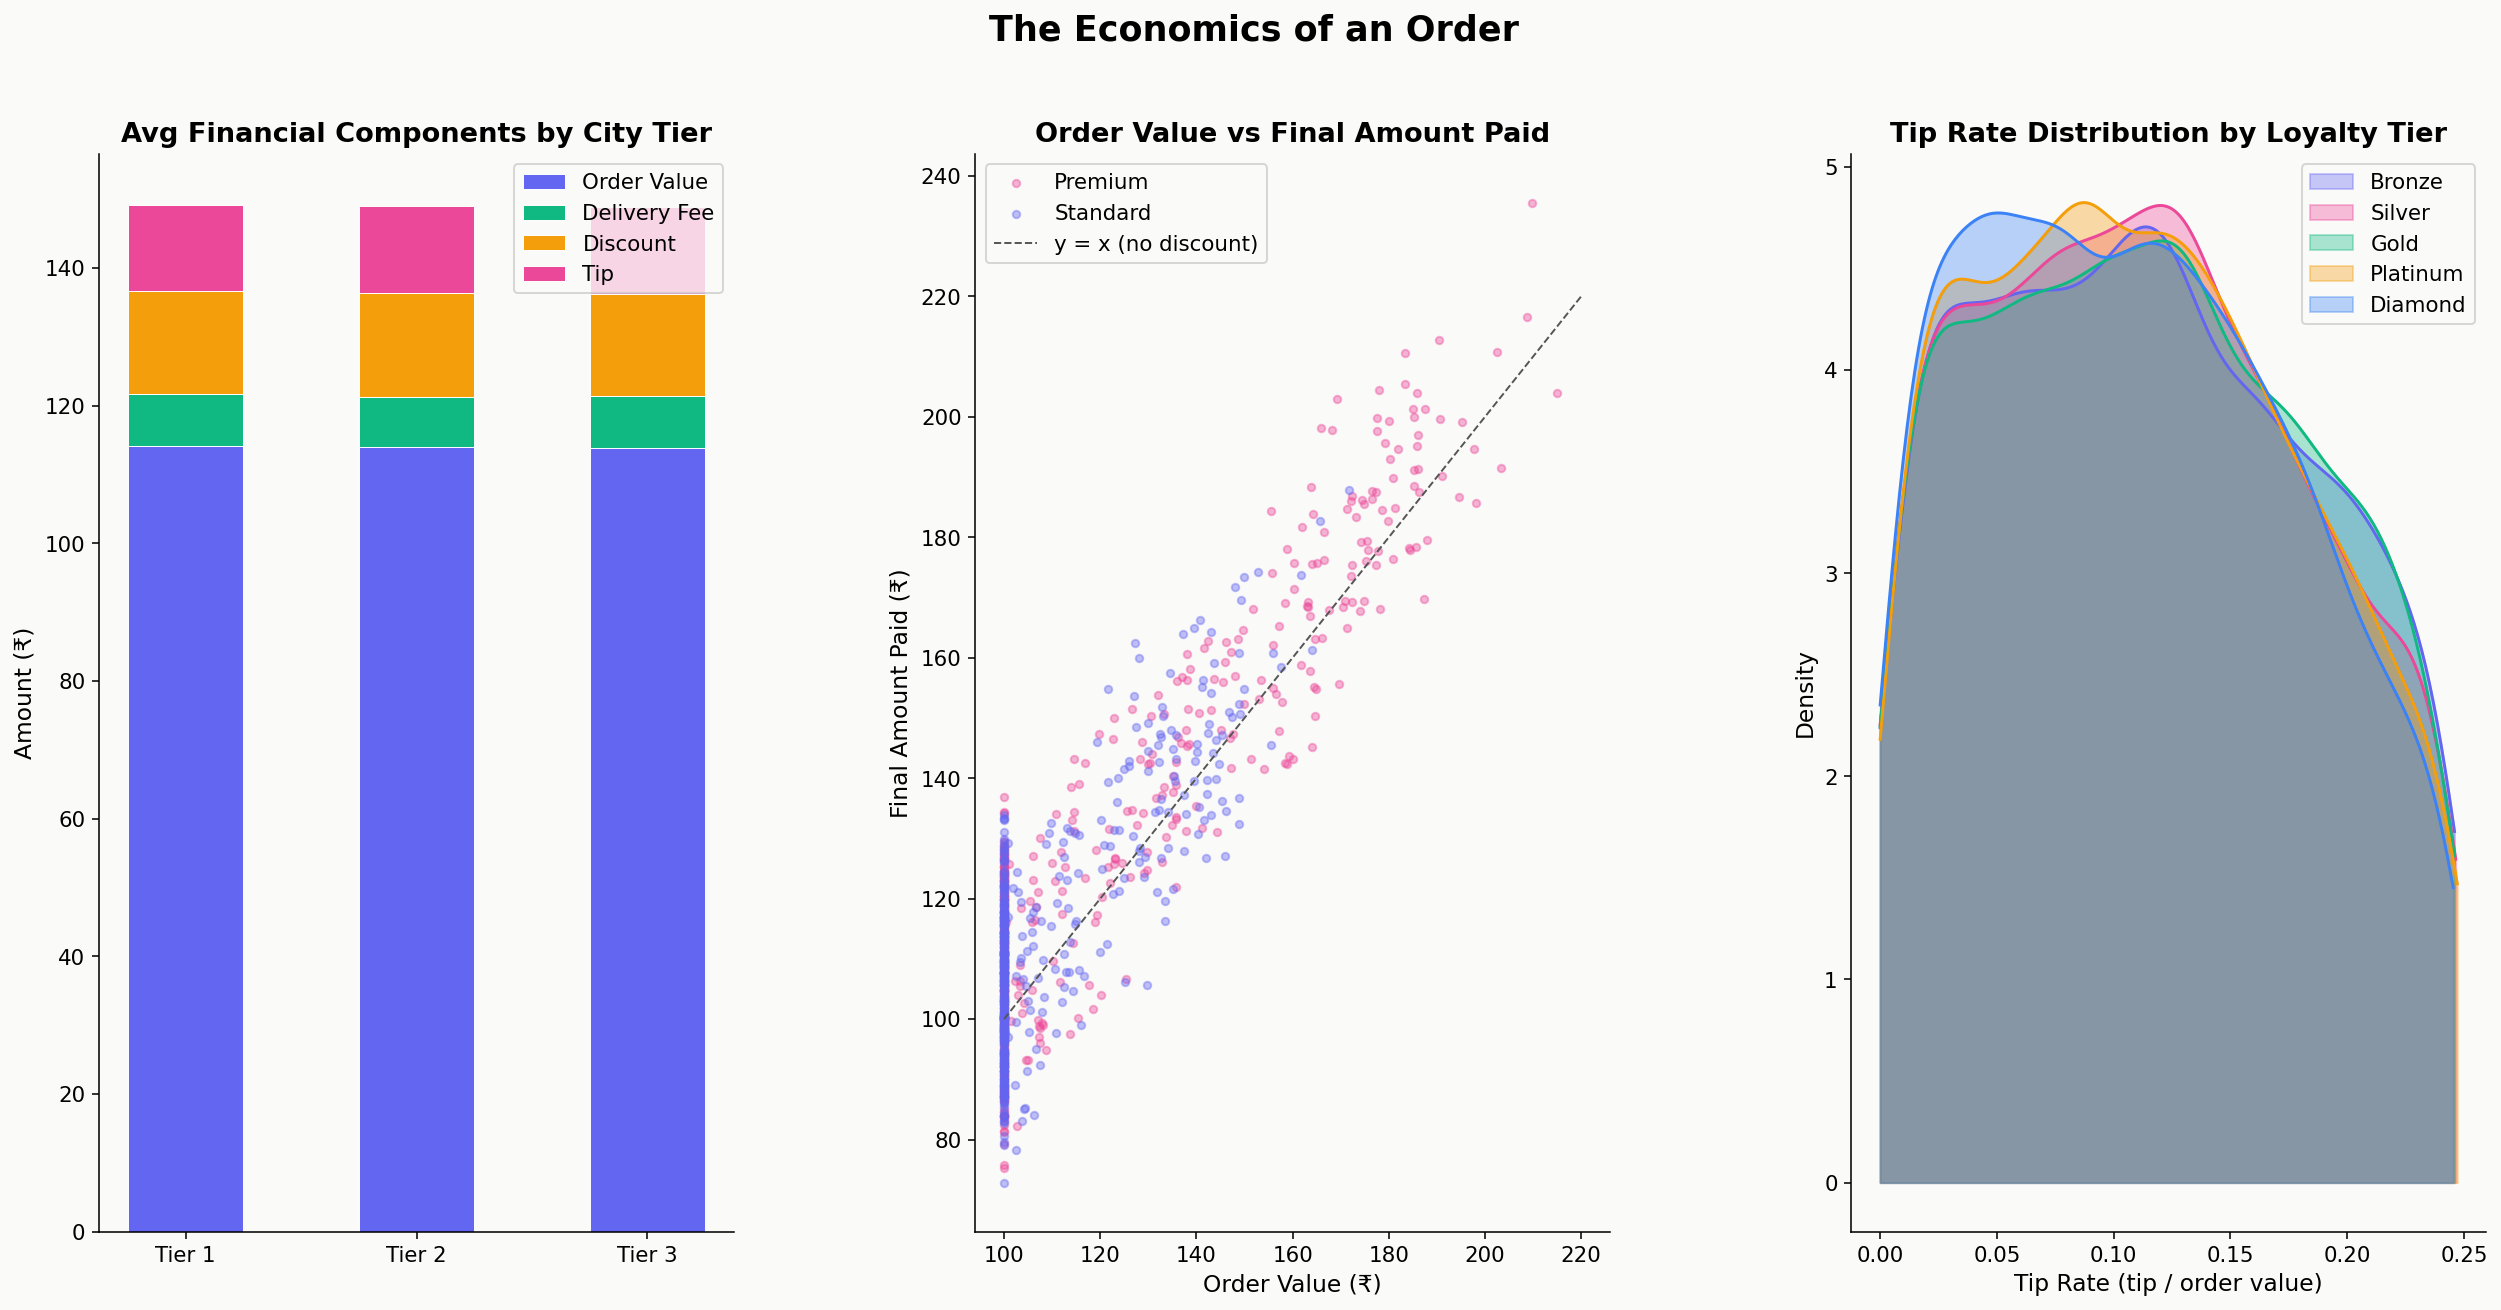

In [ ]:
fig = plt.figure(figsize=(22, 10))
fig.suptitle("The Economics of an Order", fontsize=18, fontweight="bold")
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Stacked bar: Average revenue components by city tier ─────────────────────
ax1 = fig.add_subplot(gs[0])
econ = df.groupby("city_tier")[["order_value","delivery_fee","discount_amount","tip_amount"]].mean()
bottom = np.zeros(3)
comp_colors = [PALETTE[0], PALETTE[2], PALETTE[3], PALETTE[1]]
labels_bar  = ["Order Value","Delivery Fee","Discount","Tip"]
for col, color, label in zip(econ.columns, comp_colors, labels_bar):
    ax1.bar(["Tier 1","Tier 2","Tier 3"], econ[col], bottom=bottom, color=color, label=label,
            edgecolor="white", linewidth=0.5, width=0.5)
    bottom += econ[col].values
ax1.set_title("Avg Financial Components by City Tier", fontweight="bold")
ax1.set_ylabel("Amount (₹)"); ax1.legend(loc="upper right")

# ── Scatter: Order value vs final amount paid (premium vs non) ───────────────
ax2 = fig.add_subplot(gs[1])
for flag, color, label in [(True, PALETTE[1], "Premium"), (False, PALETTE[0], "Standard")]:
    sub = df[df["premium_customer_flag"]==flag].sample(500, random_state=1)
    ax2.scatter(sub["order_value"], sub["final_amount_paid"], c=color, alpha=0.4, s=15, label=label)
ax2.plot([100,220],[100,220], color="#555", linestyle="--", linewidth=1, label="y = x (no discount)")
ax2.set_title("Order Value vs Final Amount Paid", fontweight="bold")
ax2.set_xlabel("Order Value (₹)"); ax2.set_ylabel("Final Amount Paid (₹)")
ax2.legend()

# ── KDE: Tip rate distribution by loyalty tier ───────────────────────────────
ax3 = fig.add_subplot(gs[2])
loyalty_order = ["Bronze","Silver","Gold","Platinum","Diamond"]
for tier, color in zip(loyalty_order, PALETTE[:5]):
    data = df[df["loyalty_tier"]==tier]["tip_rate"].dropna()
    if len(data) > 10:
        kde = gaussian_kde(data)
        xs  = np.linspace(0, data.quantile(0.99), 300)
        ax3.fill_between(xs, kde(xs), alpha=0.35, color=color, label=tier)
        ax3.plot(xs, kde(xs), color=color, linewidth=1.5)
ax3.set_title("Tip Rate Distribution by Loyalty Tier", fontweight="bold")
ax3.set_xlabel("Tip Rate (tip / order value)"); ax3.set_ylabel("Density")
ax3.legend()

plt.savefig("economics.png", bbox_inches="tight", dpi=150)
plt.show()

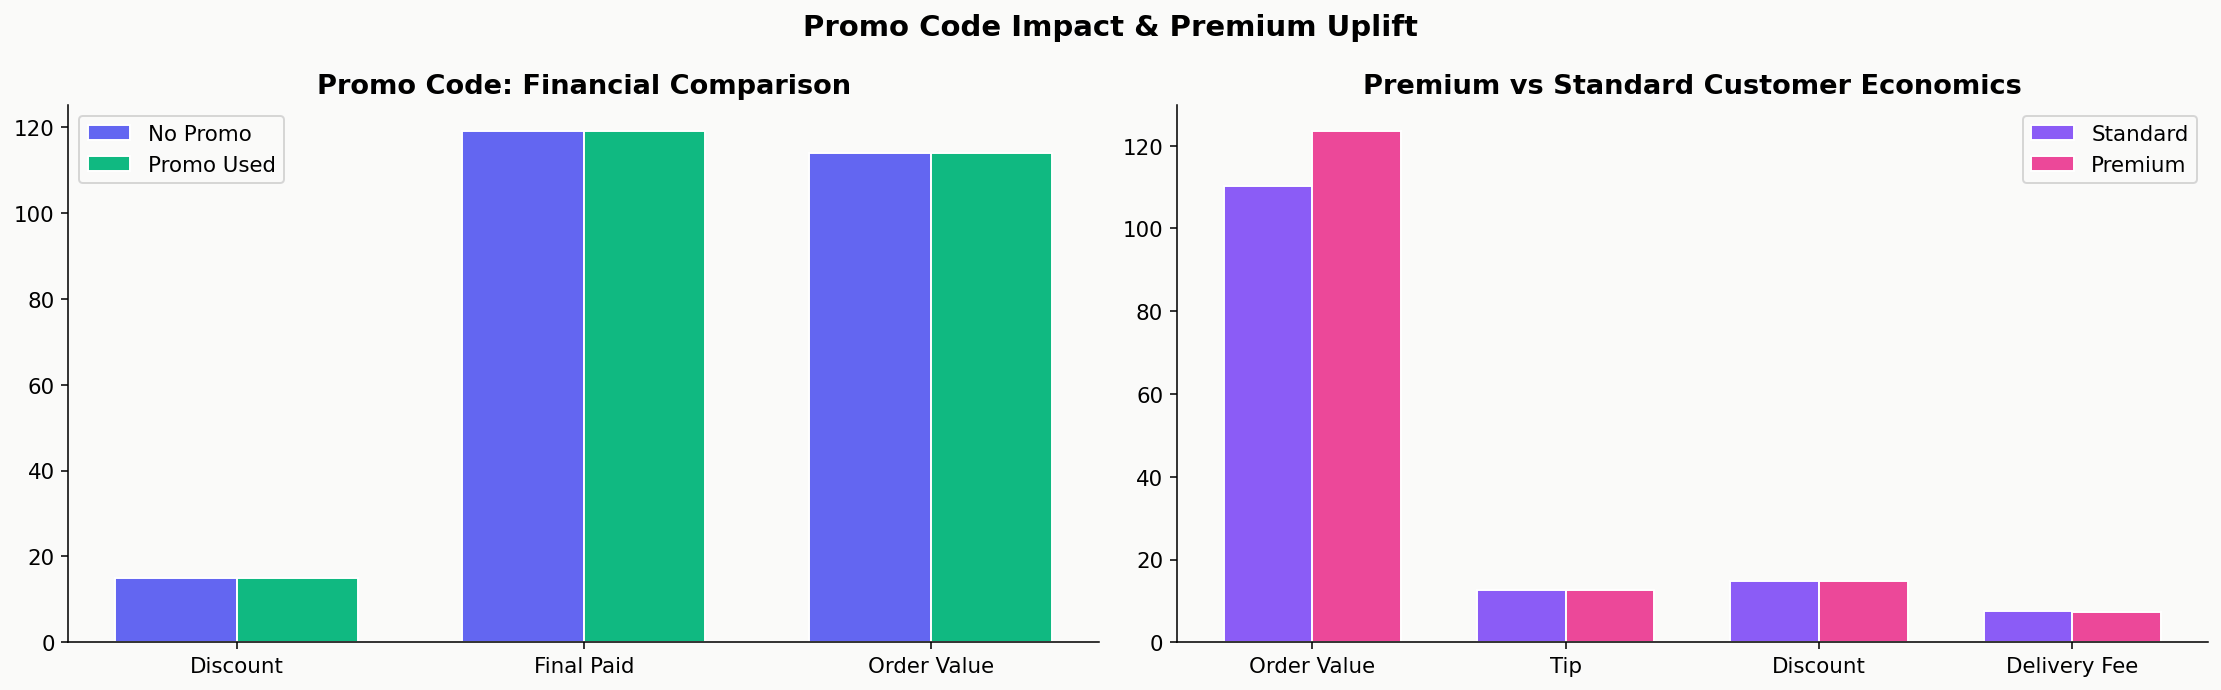

In [ ]:
# Promo code economics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Promo Code Impact & Premium Uplift", fontsize=15, fontweight="bold")

# Promo vs no promo — discount & final amount
promo_grp = df.groupby("promo_code_used")[["discount_amount","final_amount_paid","order_value"]].mean()
x = np.arange(3); w = 0.35
axes[0].bar(x - w/2, promo_grp.loc[False],  width=w, color=PALETTE[0], label="No Promo",  edgecolor="white")
axes[0].bar(x + w/2, promo_grp.loc[True],   width=w, color=PALETTE[2], label="Promo Used", edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(["Discount","Final Paid","Order Value"])
axes[0].set_title("Promo Code: Financial Comparison", fontweight="bold")
axes[0].legend()

# Premium uplift
prem_grp = df.groupby("premium_customer_flag")[["order_value","tip_amount","discount_amount","delivery_fee"]].mean()
categories = ["Order Value","Tip","Discount","Delivery Fee"]
axes[1].bar(np.arange(4) - w/2, prem_grp.loc[False], width=w, color=PALETTE[5], label="Standard", edgecolor="white")
axes[1].bar(np.arange(4) + w/2, prem_grp.loc[True],  width=w, color=PALETTE[1], label="Premium",  edgecolor="white")
axes[1].set_xticks(np.arange(4)); axes[1].set_xticklabels(categories)
axes[1].set_title("Premium vs Standard Customer Economics", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("economics2.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='9'></a>

---

## 9 — Ratings Observatory

> Three lenses of perception — restaurant, delivery partner, and customer — telling three different stories about the same meal.

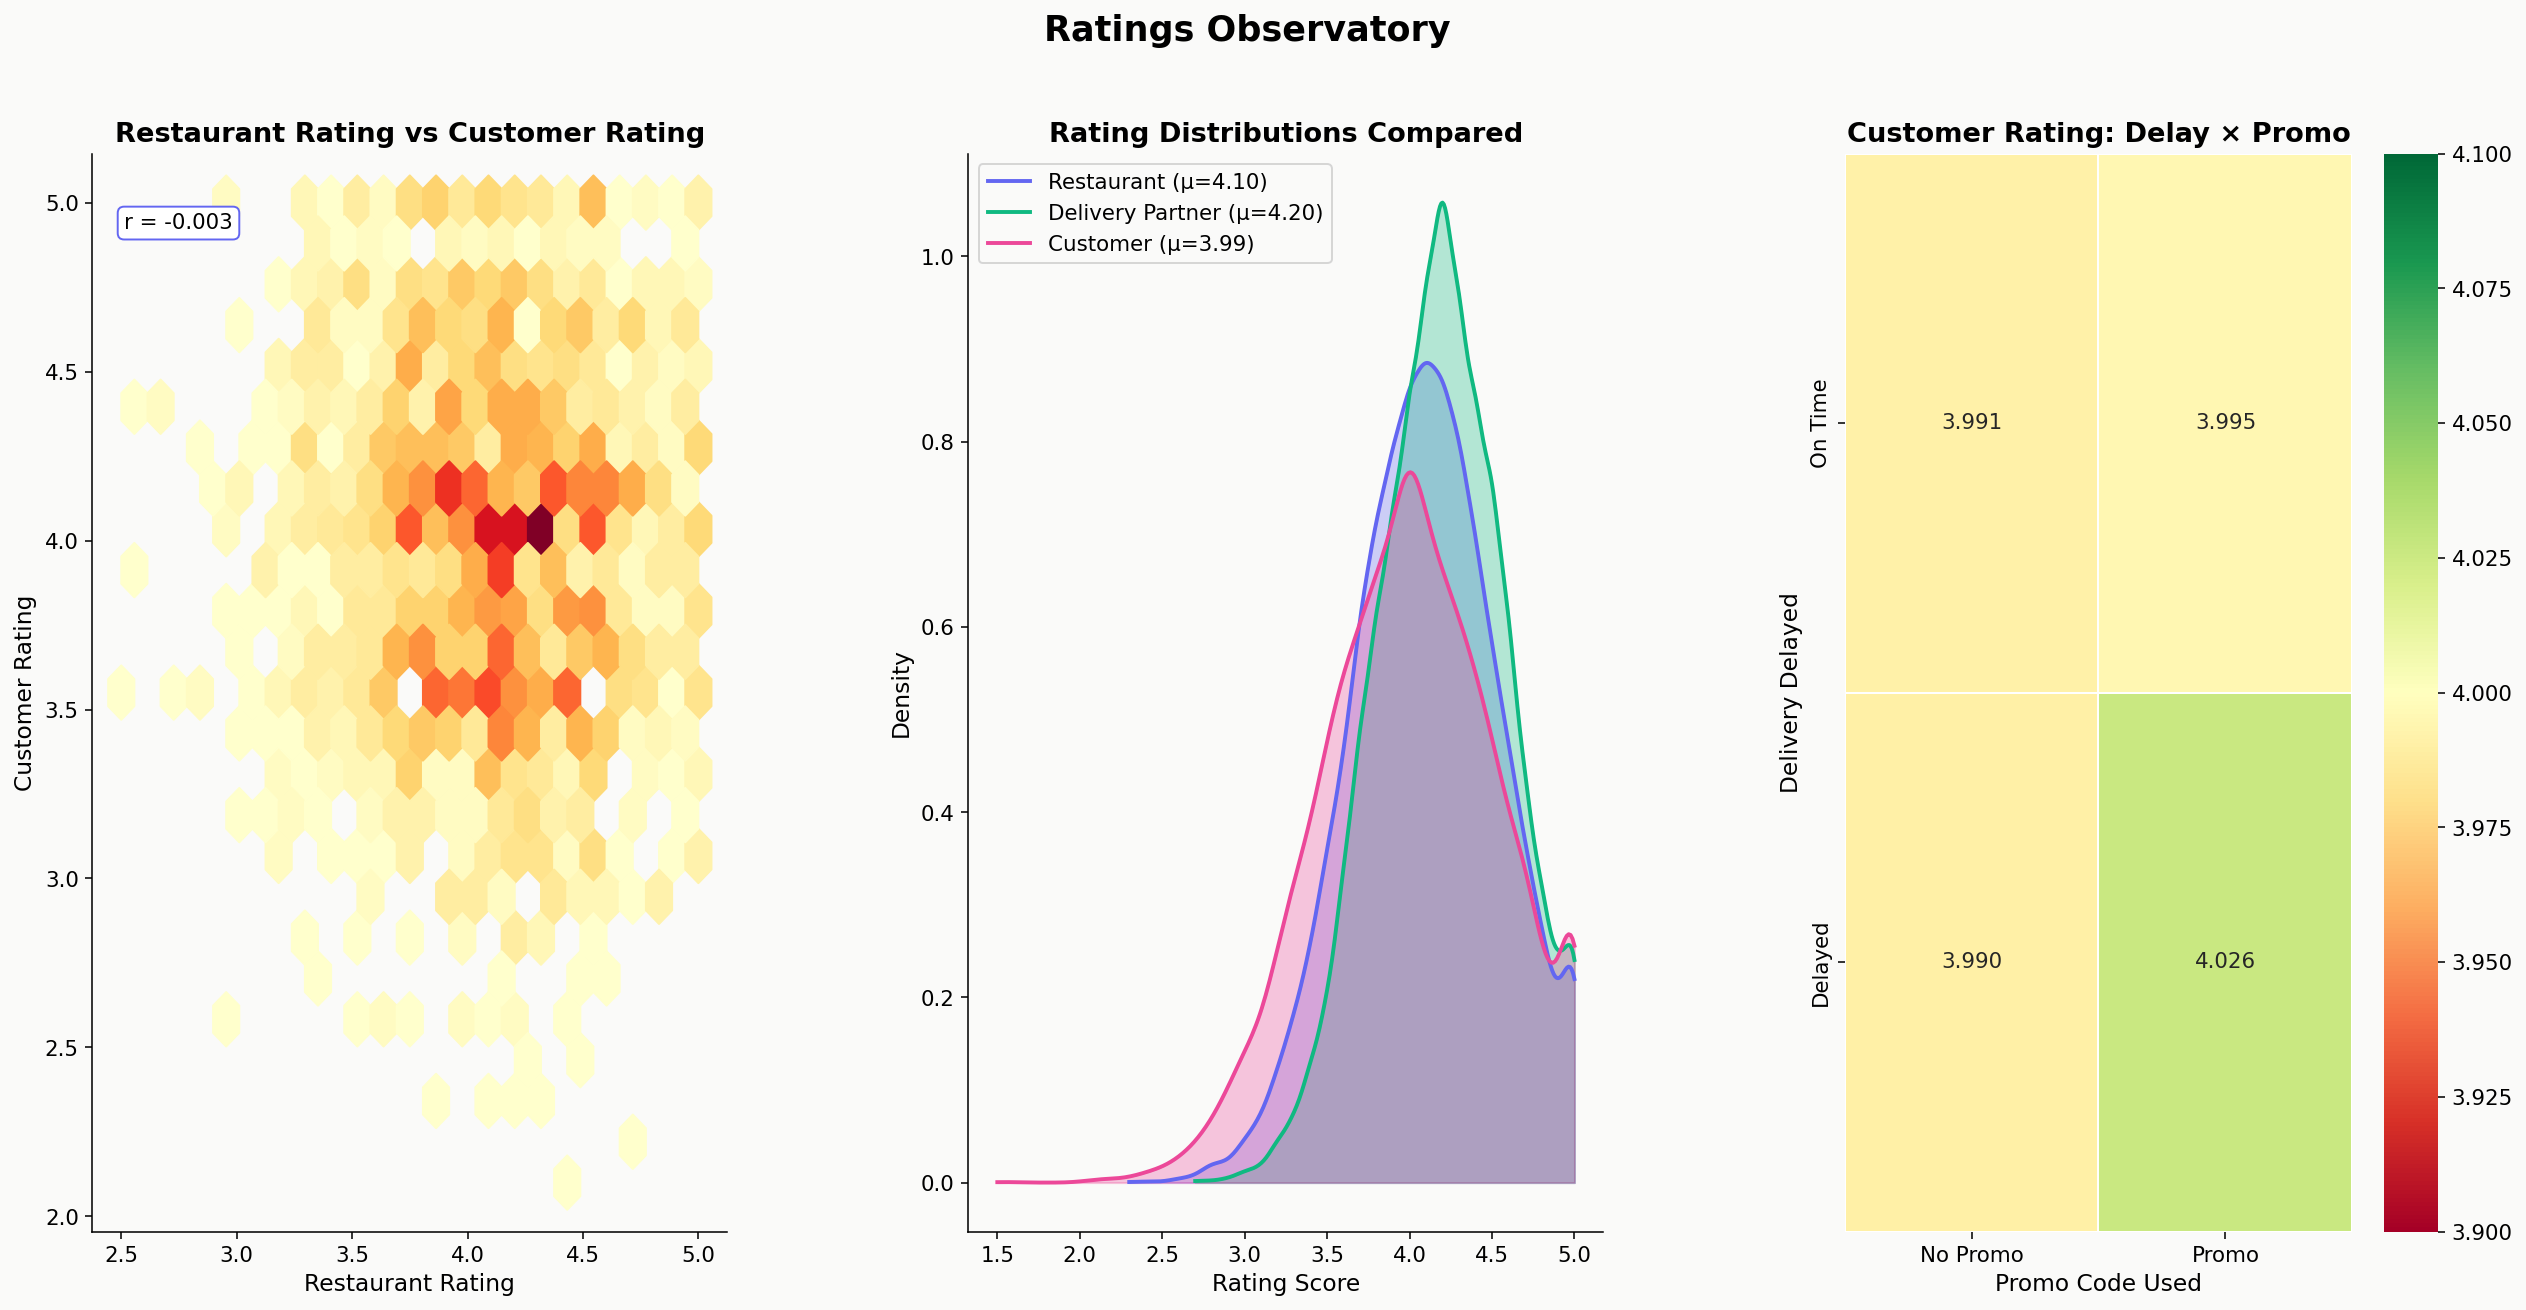

In [ ]:
fig = plt.figure(figsize=(22, 10))
fig.suptitle("Ratings Observatory", fontsize=18, fontweight="bold")
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Joint plot substitute: Restaurant rating vs Customer rating ───────────────
ax1 = fig.add_subplot(gs[0])
sample = df.sample(2000, random_state=7)
ax1.hexbin(sample["restaurant_rating"], sample["customer_rating"], gridsize=22,
           cmap="YlOrRd", mincnt=1)
ax1.set_title("Restaurant Rating vs Customer Rating", fontweight="bold")
ax1.set_xlabel("Restaurant Rating"); ax1.set_ylabel("Customer Rating")
r, p = stats.pearsonr(df["restaurant_rating"].dropna(), df["customer_rating"].dropna())
ax1.text(0.05, 0.93, f"r = {r:.3f}", transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff", edgecolor=PALETTE[0]))

# ── Rating distributions (overlapping KDE) ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])
for col, color, label in [("restaurant_rating", PALETTE[0], "Restaurant"),
                           ("delivery_partner_rating", PALETTE[2], "Delivery Partner"),
                           ("customer_rating", PALETTE[1], "Customer")]:
    data = df[col].dropna()
    kde  = gaussian_kde(data)
    xs   = np.linspace(data.min(), data.max(), 300)
    ax2.fill_between(xs, kde(xs), alpha=0.3, color=color)
    ax2.plot(xs, kde(xs), color=color, linewidth=2, label=f"{label} (μ={data.mean():.2f})")
ax2.set_title("Rating Distributions Compared", fontweight="bold")
ax2.set_xlabel("Rating Score"); ax2.set_ylabel("Density")
ax2.legend()

# ── Average customer rating by delay × promo ─────────────────────────────────
ax3 = fig.add_subplot(gs[2])
pivot = df.pivot_table(values="customer_rating",
                       index="delayed_delivery_flag",
                       columns="promo_code_used",
                       aggfunc="mean")
sns.heatmap(pivot, ax=ax3, cmap="RdYlGn", annot=True, fmt=".3f",
            linewidths=1, linecolor="white",
            xticklabels=["No Promo","Promo"],
            yticklabels=["On Time","Delayed"],
            vmin=3.9, vmax=4.1)
ax3.set_title("Customer Rating: Delay × Promo", fontweight="bold")
ax3.set_xlabel("Promo Code Used"); ax3.set_ylabel("Delivery Delayed")

plt.savefig("ratings.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='10'></a>

---

## 10 — Operational Risk: Delays, Cancellations & Refunds

> Every business has fracture lines. Here we map the three that matter most.

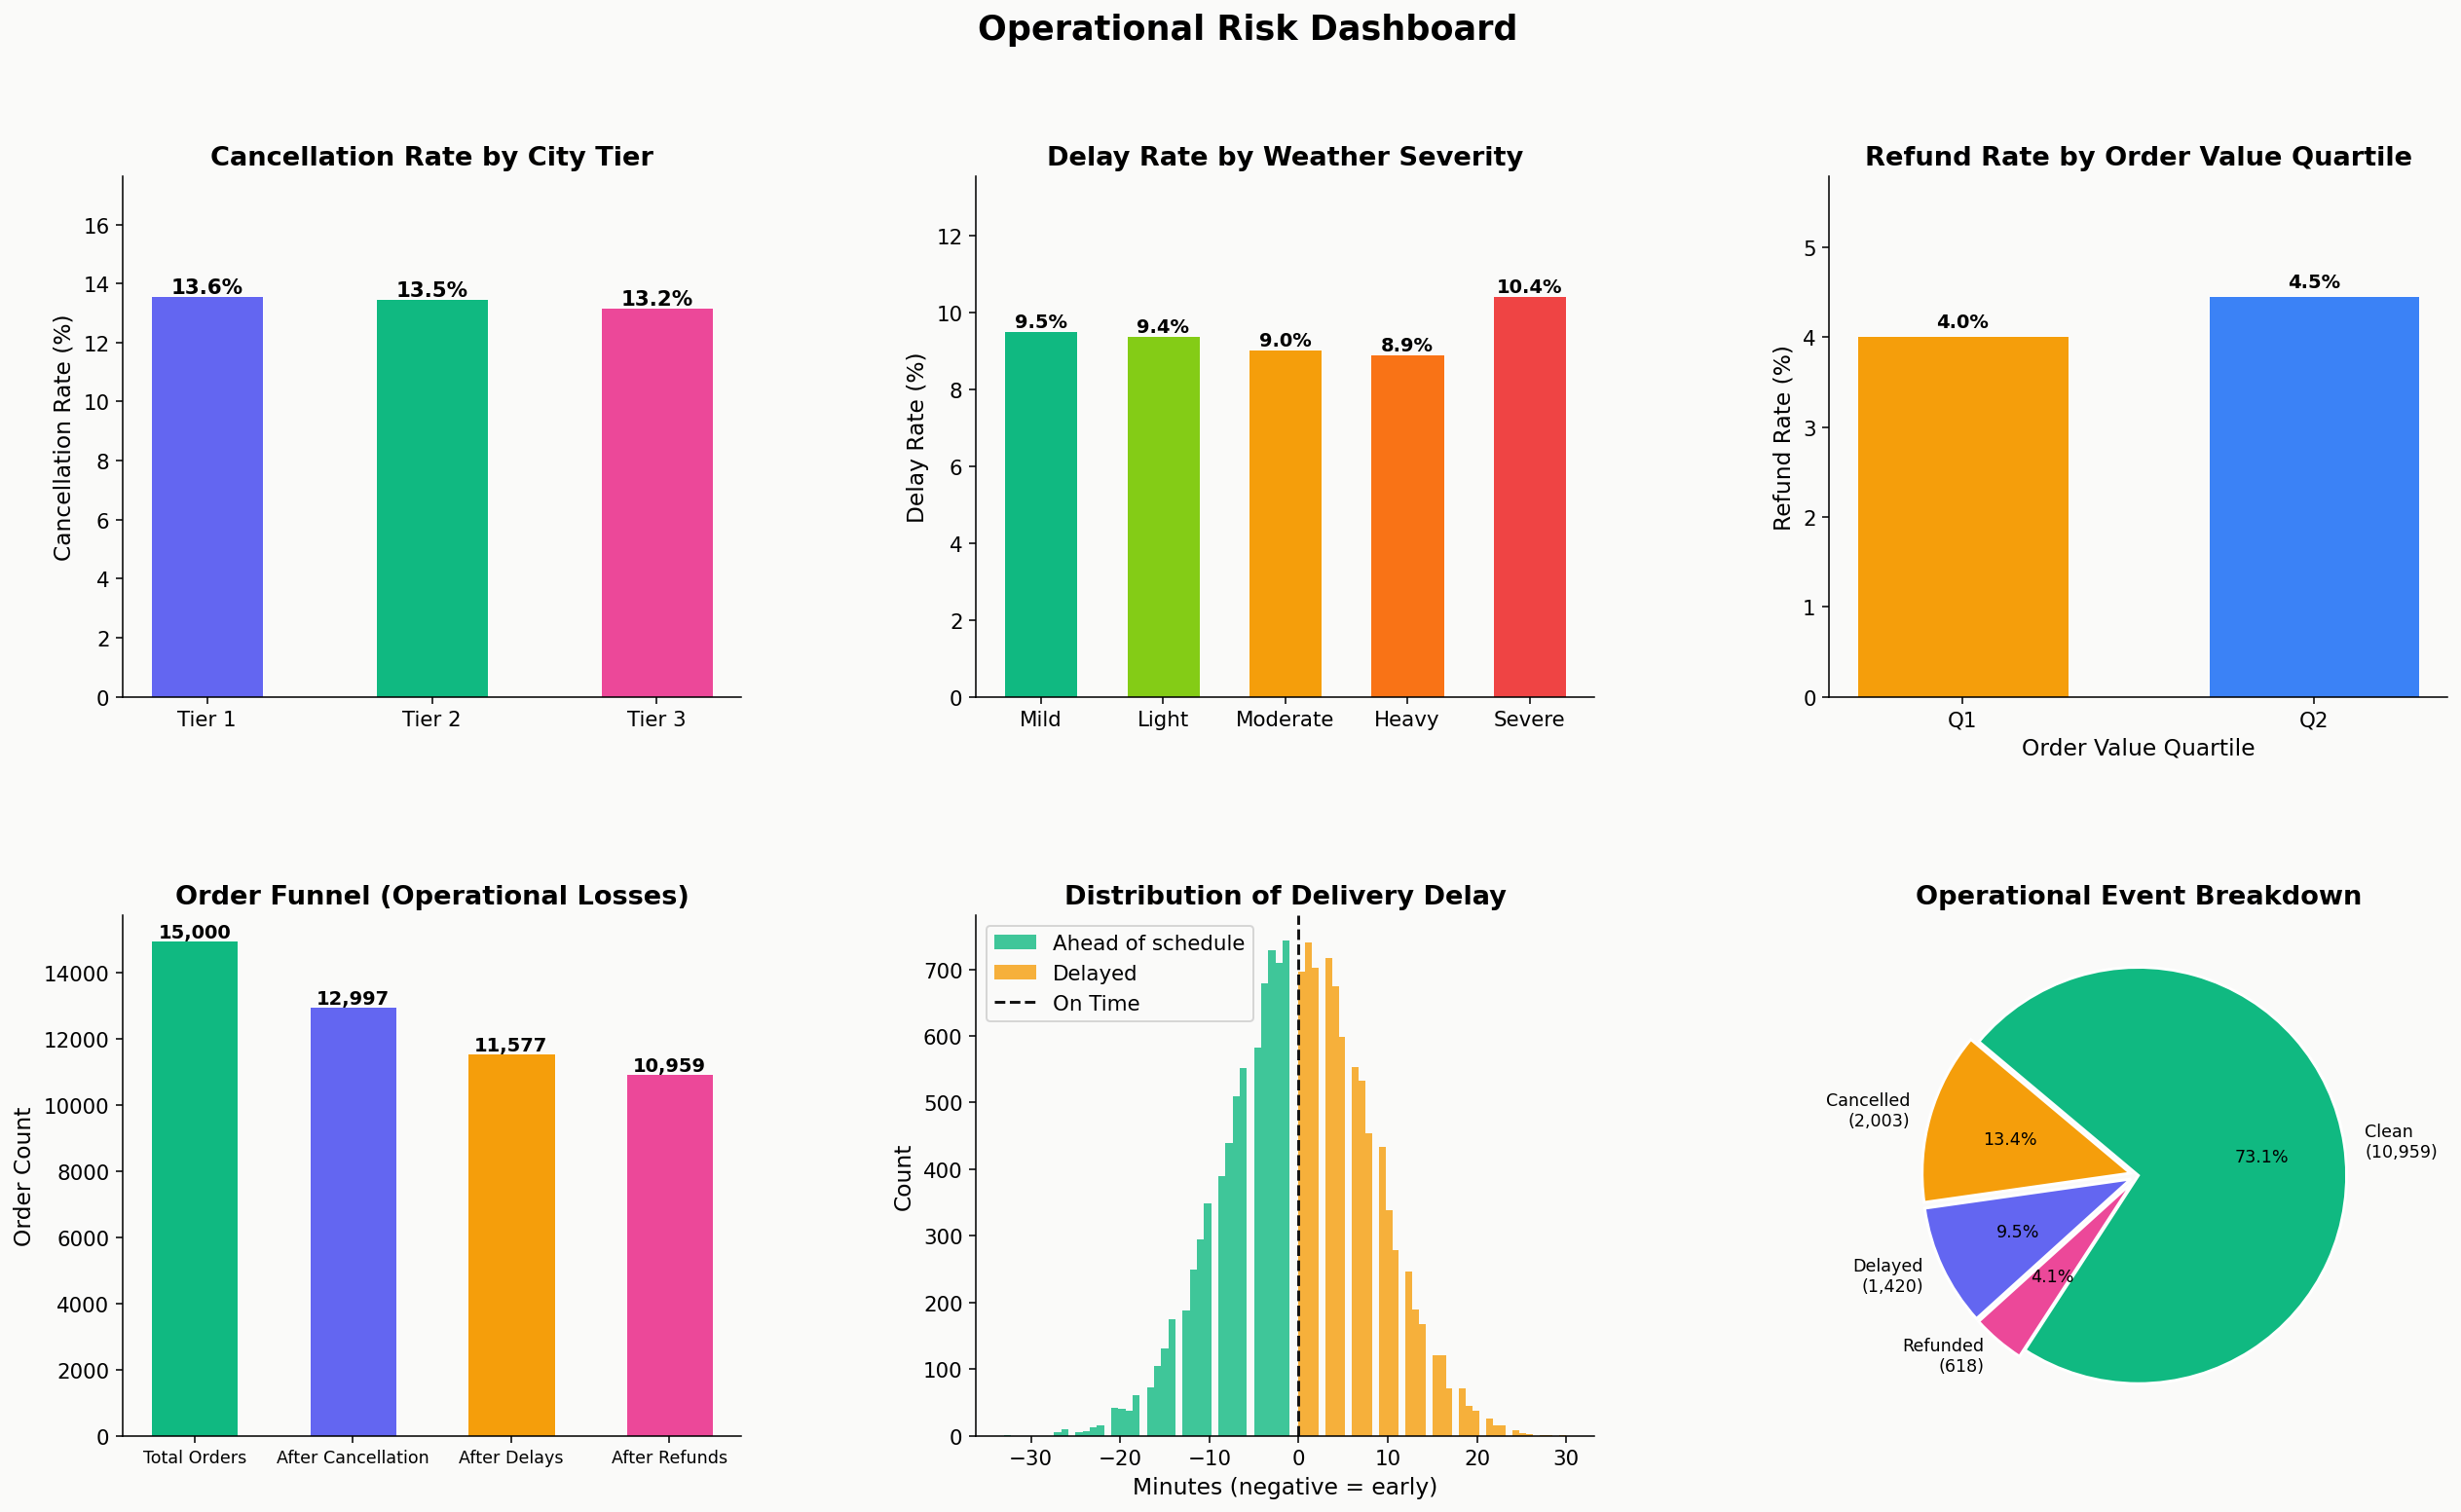

In [ ]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle("Operational Risk Dashboard", fontsize=18, fontweight="bold")
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Cancellation rate by city tier ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

cancel_rate = df.groupby("city_tier")["cancellation_flag"].mean() * 100

bars = ax1.bar(
    ["Tier 1", "Tier 2", "Tier 3"],
    cancel_rate,
    color=[PALETTE[0], PALETTE[2], PALETTE[1]],
    edgecolor="white",
    linewidth=0.5,
    width=0.5
)

for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{bar.get_height():.1f}%", ha="center",
             fontsize=11, fontweight="bold")

ax1.set_title("Cancellation Rate by City Tier", fontweight="bold")
ax1.set_ylabel("Cancellation Rate (%)")
ax1.set_ylim(0, cancel_rate.max()*1.3)

# ── Delay flag rate by weather ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

weather_delay = df.groupby("weather_bucket")["delayed_delivery_flag"].mean() * 100

weather_colors = ["#10b981", "#84cc16", "#f59e0b", "#f97316", "#ef4444"]

bars2 = ax2.bar(
    weather_delay.index,
    weather_delay.values,
    color=weather_colors[:len(weather_delay)],
    edgecolor="white",
    linewidth=0.5,
    width=0.6
)

for bar in bars2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{bar.get_height():.1f}%", ha="center",
             fontsize=10, fontweight="bold")

ax2.set_title("Delay Rate by Weather Severity", fontweight="bold")
ax2.set_ylabel("Delay Rate (%)")
ax2.set_ylim(0, weather_delay.max()*1.3)

# ── Refund rate by order value quartile ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

df["order_value_q"] = pd.qcut(df["order_value"], q=4, duplicates="drop")

refund_q = df.groupby("order_value_q")["refund_flag"].mean() * 100

labels_q = [f"Q{i+1}" for i in range(len(refund_q.index))]

bars3 = ax3.bar(
    labels_q,
    refund_q.values,
    color=PALETTE[3:3+len(labels_q)],
    edgecolor="white",
    linewidth=0.5,
    width=0.6
)

for bar in bars3:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{bar.get_height():.1f}%", ha="center",
             fontsize=10, fontweight="bold")

ax3.set_title("Refund Rate by Order Value Quartile", fontweight="bold")
ax3.set_ylabel("Refund Rate (%)")
ax3.set_xlabel("Order Value Quartile")
ax3.set_ylim(0, refund_q.max()*1.3)

# ── Waterfall: Total orders → delivered → flagged ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

total = len(df)
cancelled = df["cancellation_flag"].sum()
delayed = df["delayed_delivery_flag"].sum()
refunded = df["refund_flag"].sum()

labels = ["Total Orders", "After Cancellation", "After Delays", "After Refunds"]

values = [
    total,
    total-cancelled,
    total-cancelled-delayed,
    total-cancelled-delayed-refunded
]

waterfall_colors = [PALETTE[2], PALETTE[0], PALETTE[3], PALETTE[1]]

bars4 = ax4.bar(
    labels,
    values,
    color=waterfall_colors,
    edgecolor="white",
    linewidth=0.5,
    width=0.55
)

for i, v in enumerate(values):
    ax4.text(i, v+80, f"{v:,}", ha="center",
             fontsize=10, fontweight="bold")

ax4.set_title("Order Funnel (Operational Losses)", fontweight="bold")
ax4.set_ylabel("Order Count")
ax4.tick_params(axis="x", labelsize=9)

# ── Delay minutes distribution ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])

delay_vals = df["delivery_delay_minutes"]

ax5.hist(delay_vals[delay_vals < 0], bins=40,
         color=PALETTE[2], alpha=0.8,
         label="Ahead of schedule")

ax5.hist(delay_vals[delay_vals >= 0], bins=40,
         color=PALETTE[3], alpha=0.8,
         label="Delayed")

ax5.axvline(0, color="#111", linestyle="--",
            linewidth=1.5, label="On Time")

ax5.set_title("Distribution of Delivery Delay", fontweight="bold")
ax5.set_xlabel("Minutes (negative = early)")
ax5.set_ylabel("Count")
ax5.legend()

# ── Pie: Risk event breakdown ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])

clean_orders = total - cancelled - delayed - refunded

sizes = [cancelled, delayed, refunded, clean_orders]

labels_pie = [
    f"Cancelled\n({cancelled:,})",
    f"Delayed\n({delayed:,})",
    f"Refunded\n({refunded:,})",
    f"Clean\n({clean_orders:,})"
]

explode = [0.04, 0.04, 0.04, 0]

wedge_colors = [PALETTE[3], PALETTE[0], PALETTE[1], PALETTE[2]]

ax6.pie(
    sizes,
    labels=labels_pie,
    colors=wedge_colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 9},
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
)

ax6.set_title("Operational Event Breakdown", fontweight="bold")

plt.savefig("risk.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='11'></a>

---

## 11 — Partner Experience & Performance

> Behind every delivery is a human. How does their journey shape yours?

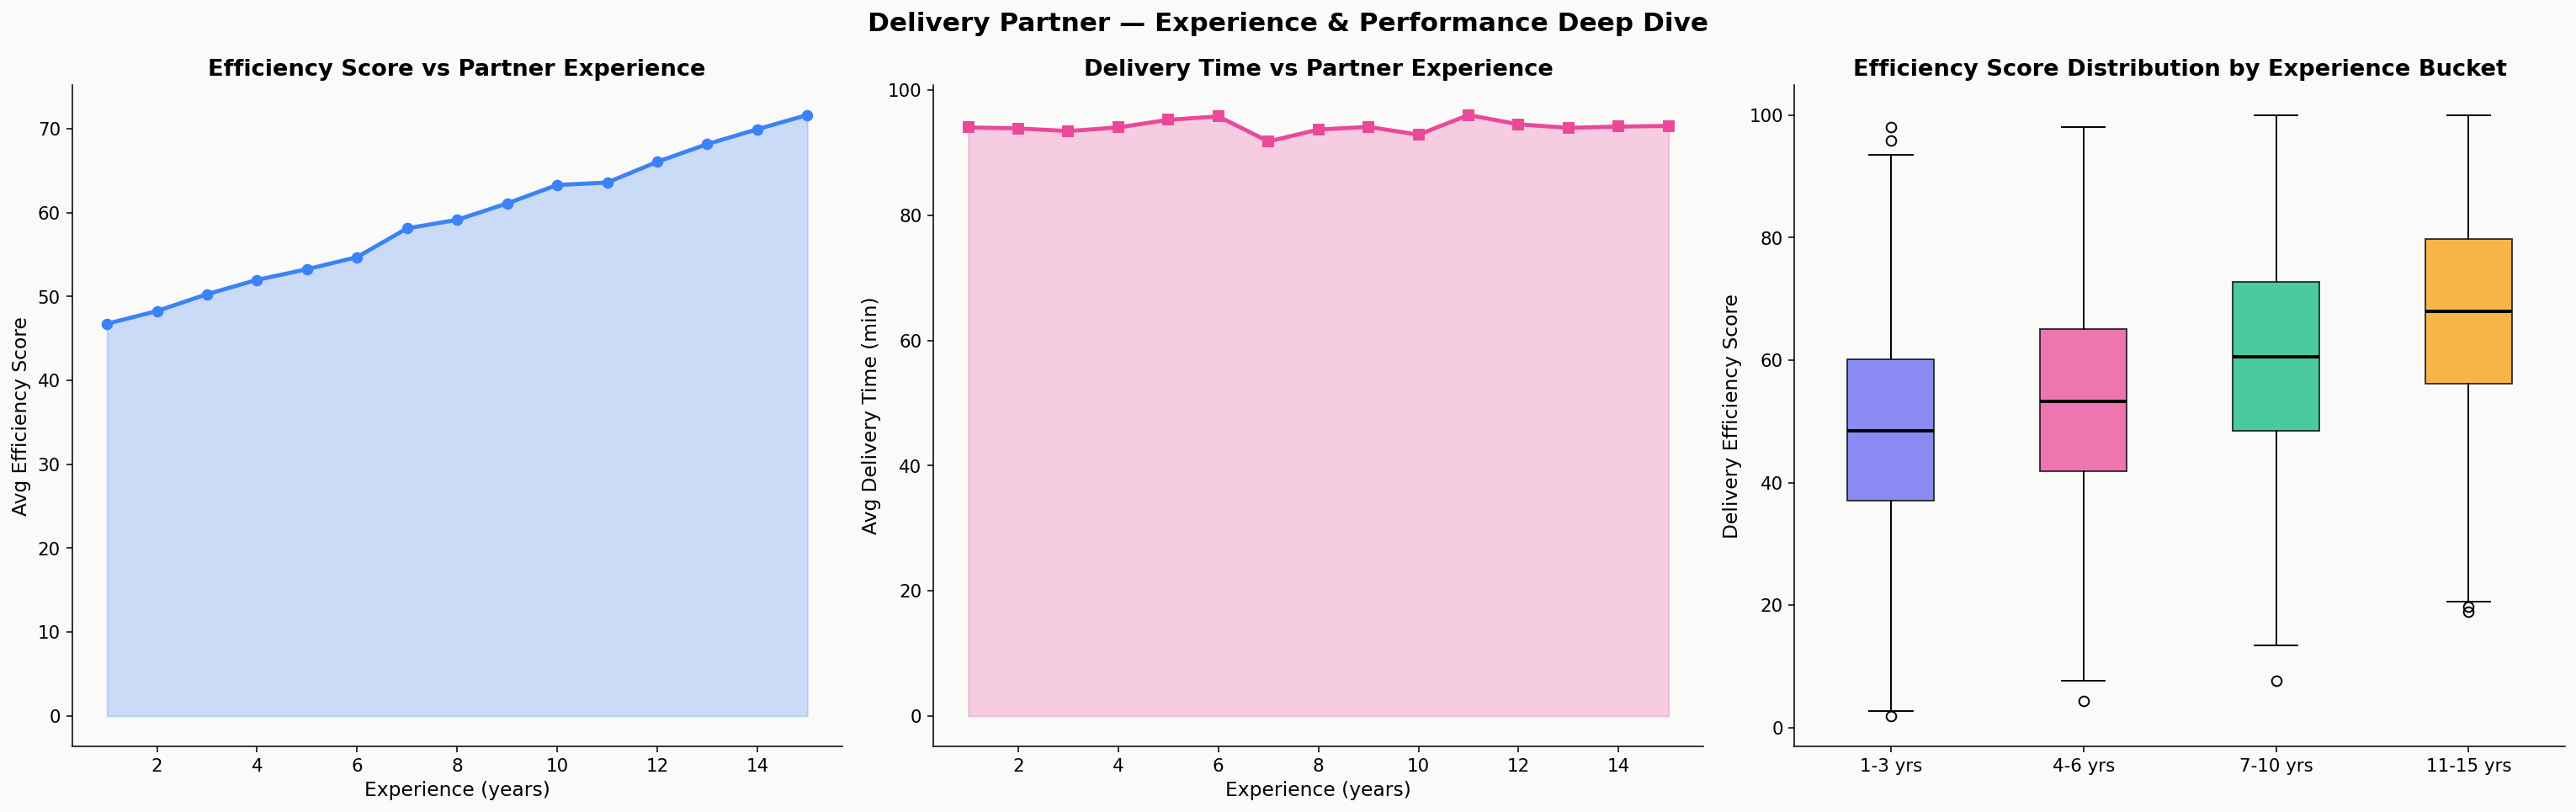

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Delivery Partner — Experience & Performance Deep Dive", fontsize=16, fontweight="bold")
fig.patch.set_facecolor(BG)

# ── Efficiency score by experience (area chart) ───────────────────────────────
exp_data = df.groupby("delivery_partner_experience_years").agg(
    avg_eff   = ("delivery_efficiency_score","mean"),
    avg_time  = ("delivery_time_minutes","mean"),
    avg_rating= ("customer_rating","mean")
).reset_index()
axes[0].fill_between(exp_data["delivery_partner_experience_years"], exp_data["avg_eff"],
                     alpha=0.25, color=PALETTE[4])
axes[0].plot(exp_data["delivery_partner_experience_years"], exp_data["avg_eff"],
             color=PALETTE[4], linewidth=2.5, marker="o", markersize=6)
axes[0].set_title("Efficiency Score vs Partner Experience", fontweight="bold")
axes[0].set_xlabel("Experience (years)"); axes[0].set_ylabel("Avg Efficiency Score")

# ── Delivery time vs experience (declining) ───────────────────────────────────
axes[1].fill_between(exp_data["delivery_partner_experience_years"], exp_data["avg_time"],
                     alpha=0.25, color=PALETTE[1])
axes[1].plot(exp_data["delivery_partner_experience_years"], exp_data["avg_time"],
             color=PALETTE[1], linewidth=2.5, marker="s", markersize=6)
axes[1].set_title("Delivery Time vs Partner Experience", fontweight="bold")
axes[1].set_xlabel("Experience (years)"); axes[1].set_ylabel("Avg Delivery Time (min)")

# ── Box: Efficiency score by experience bucket ────────────────────────────────
df["exp_bucket"] = pd.cut(df["delivery_partner_experience_years"], bins=[0,3,6,10,15],
                          labels=["1-3 yrs","4-6 yrs","7-10 yrs","11-15 yrs"])
exp_bp_data = [df[df["exp_bucket"]==b]["delivery_efficiency_score"].dropna()
               for b in ["1-3 yrs","4-6 yrs","7-10 yrs","11-15 yrs"]]
bp = axes[2].boxplot(exp_bp_data, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], PALETTE[:4]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[2].set_xticklabels(["1-3 yrs","4-6 yrs","7-10 yrs","11-15 yrs"])
axes[2].set_title("Efficiency Score Distribution by Experience Bucket", fontweight="bold")
axes[2].set_ylabel("Delivery Efficiency Score")

plt.tight_layout()
plt.savefig("partner.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='12'></a>

---

## 12 — Customer Segmentation: Loyalty, Age & Premium Status

> Who orders? What defines them? How do they differ in wallet and behaviour?


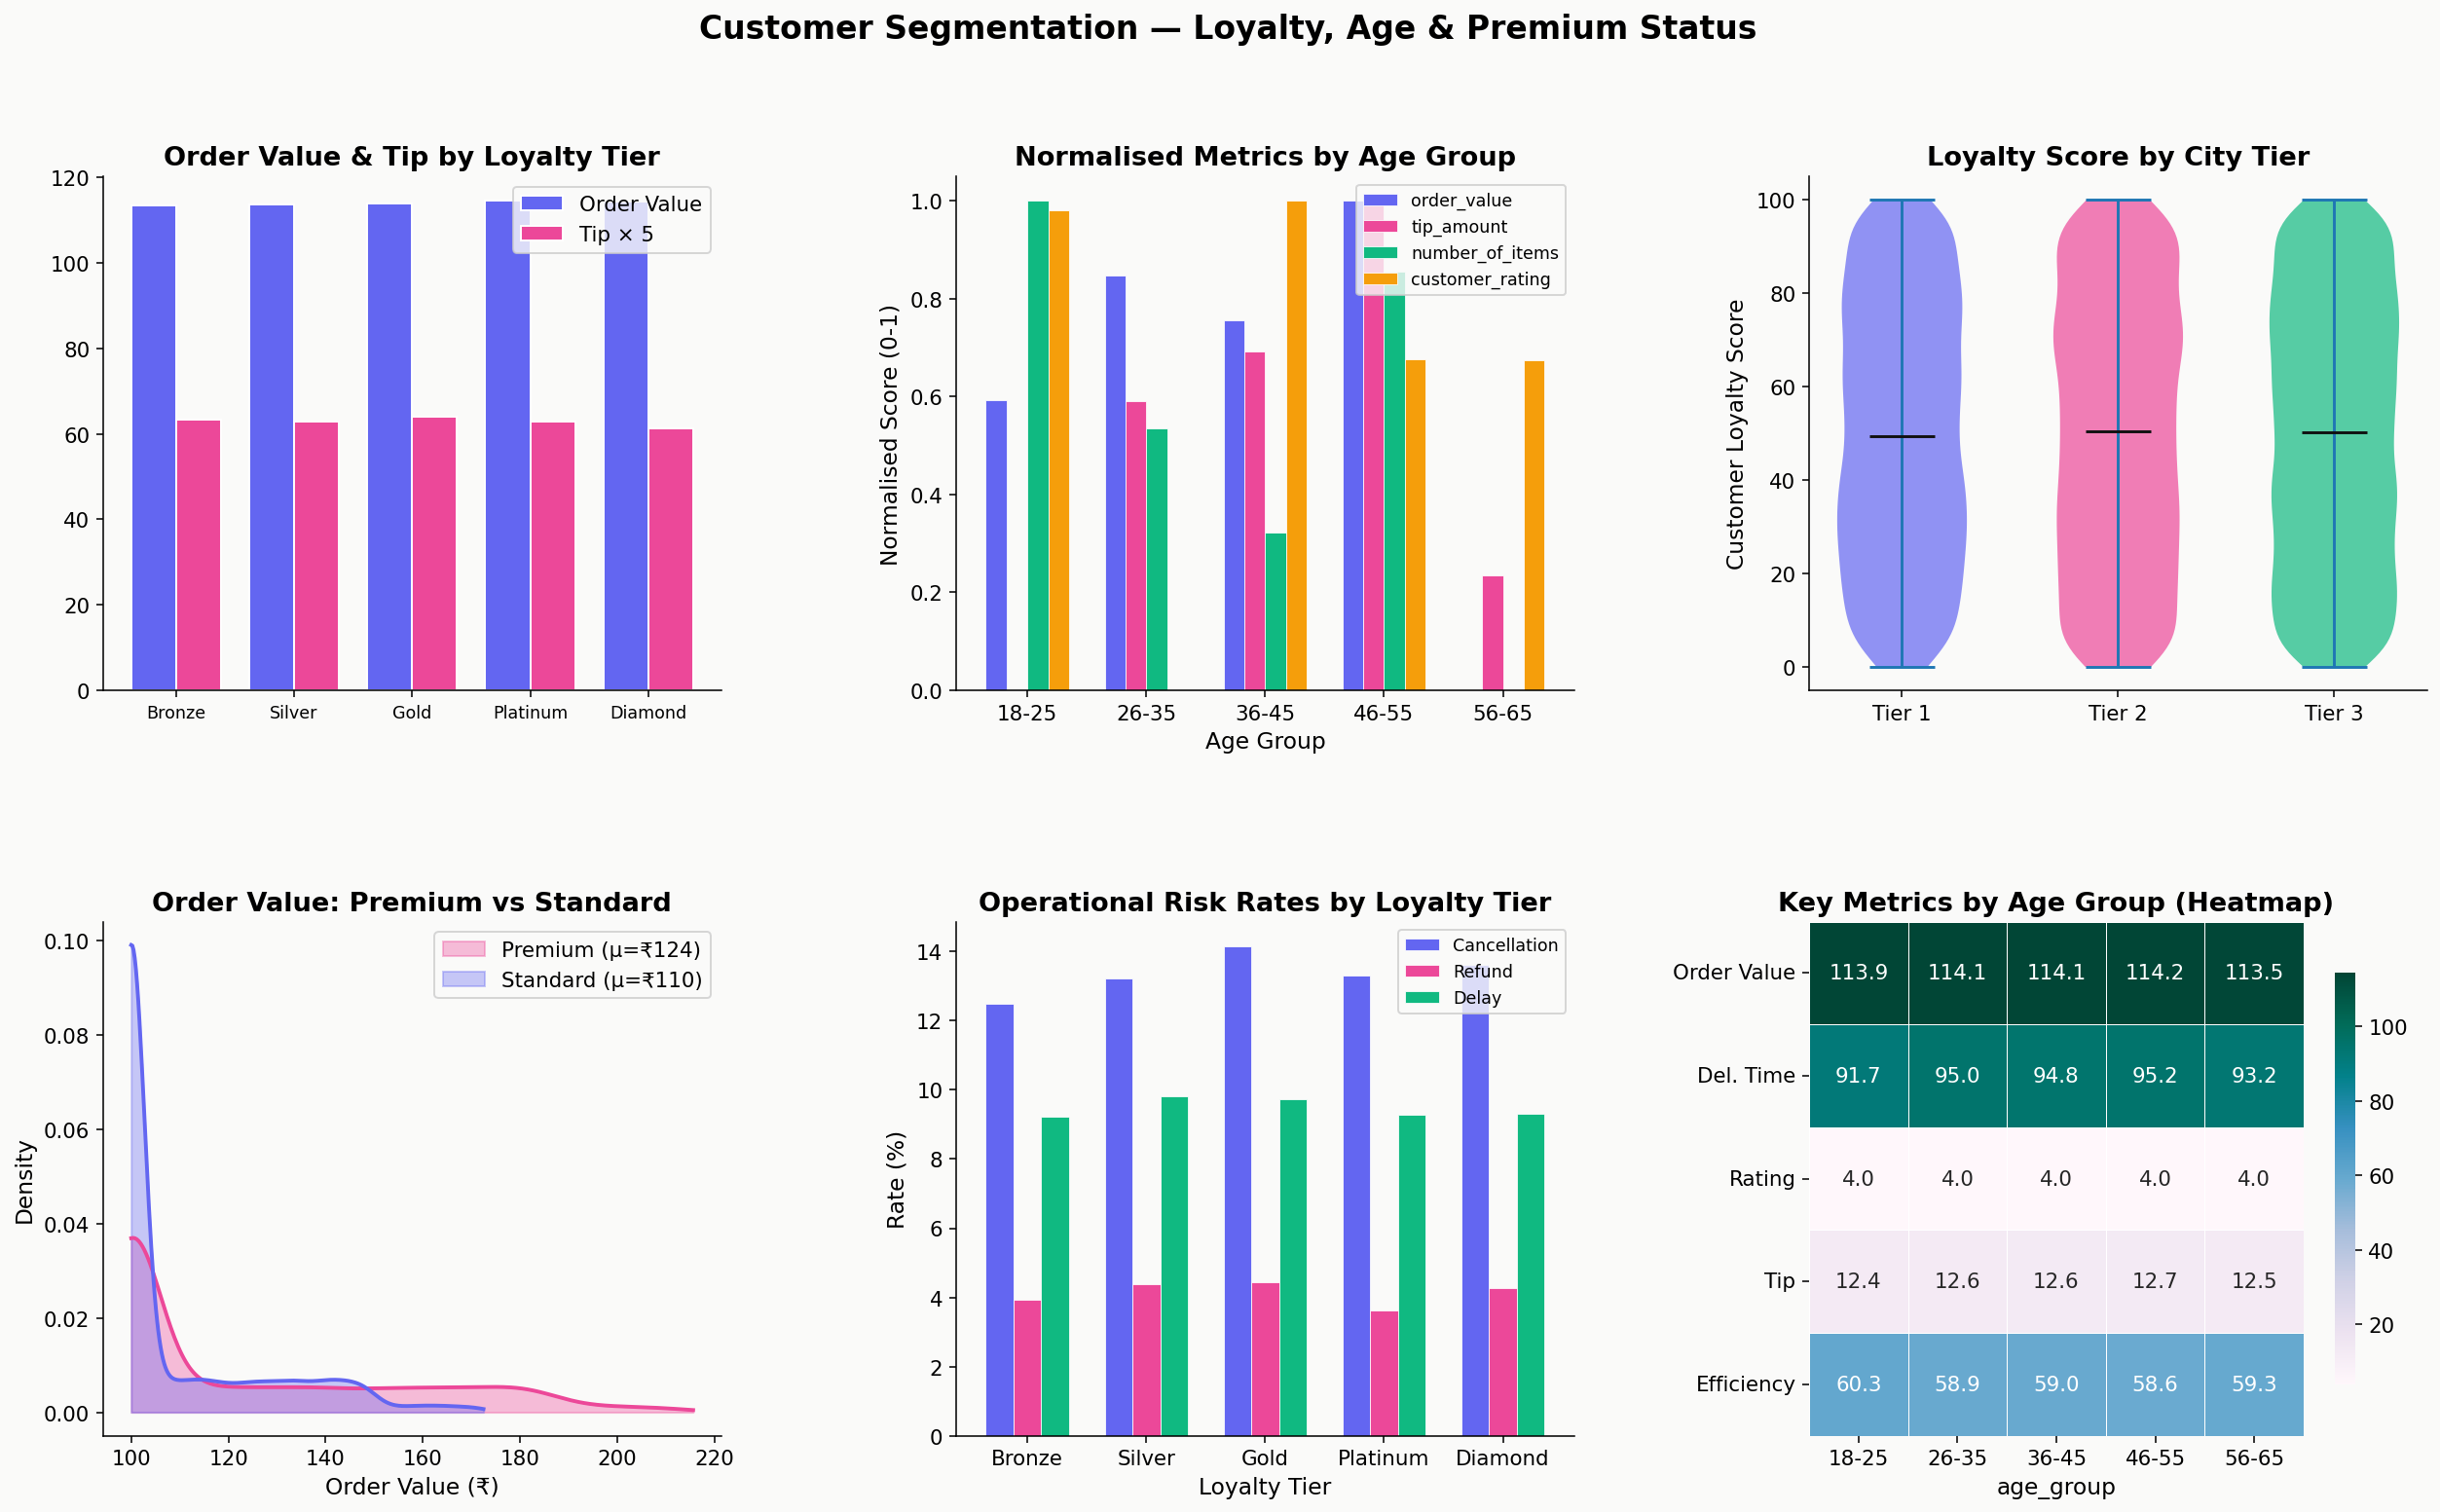

In [ ]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle("Customer Segmentation — Loyalty, Age & Premium Status", fontsize=17, fontweight="bold")
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Loyalty tier: order value and tip ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
loyalty_data = df.groupby("loyalty_tier")[["order_value","tip_amount"]].mean()
x = np.arange(5); w = 0.38
ax1.bar(x - w/2, loyalty_data["order_value"], width=w, color=PALETTE[0], label="Order Value", edgecolor="white")
ax1.bar(x + w/2, loyalty_data["tip_amount"]*5, width=w, color=PALETTE[1], label="Tip × 5", edgecolor="white")
ax1.set_xticks(x); ax1.set_xticklabels(["Bronze","Silver","Gold","Platinum","Diamond"], fontsize=9)
ax1.set_title("Order Value & Tip by Loyalty Tier", fontweight="bold")
ax1.legend()

# ── Age group radar substitute: multi-metric bar ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
age_data = df.groupby("age_group")[["order_value","tip_amount","number_of_items","customer_rating"]].mean()
age_data_norm = (age_data - age_data.min()) / (age_data.max() - age_data.min())
age_data_norm.plot(kind="bar", ax=ax2, color=PALETTE[:4], edgecolor="white", linewidth=0.4, width=0.7)
ax2.set_title("Normalised Metrics by Age Group", fontweight="bold")
ax2.set_xlabel("Age Group"); ax2.set_ylabel("Normalised Score (0-1)")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(fontsize=9)

# ── Loyalty score distribution (violin per city tier) ─────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
tier_loyalty = [df[df["city_tier"]==t]["customer_loyalty_score"].values for t in [1,2,3]]
vp = ax3.violinplot(tier_loyalty, positions=[1,2,3], showmedians=True, widths=0.6)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(PALETTE[i]); body.set_alpha(0.7)
vp["cmedians"].set_color("#111")
ax3.set_xticks([1,2,3]); ax3.set_xticklabels(["Tier 1","Tier 2","Tier 3"])
ax3.set_title("Loyalty Score by City Tier", fontweight="bold")
ax3.set_ylabel("Customer Loyalty Score")

# ── Premium: order value distribution ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for flag, color, label in [(True, PALETTE[1], "Premium"), (False, PALETTE[0], "Standard")]:
    data = df[df["premium_customer_flag"]==flag]["order_value"]
    kde  = gaussian_kde(data)
    xs   = np.linspace(data.min(), data.max(), 300)
    ax4.fill_between(xs, kde(xs), alpha=0.35, color=color, label=f"{label} (μ=₹{data.mean():.0f})")
    ax4.plot(xs, kde(xs), color=color, linewidth=2)
ax4.set_title("Order Value: Premium vs Standard", fontweight="bold")
ax4.set_xlabel("Order Value (₹)"); ax4.set_ylabel("Density")
ax4.legend()

# ── Loyalty tier: cancellation and refund rates ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
loyalty_risk = df.groupby("loyalty_tier")[["cancellation_flag","refund_flag","delayed_delivery_flag"]].mean() * 100
loyalty_risk.plot(kind="bar", ax=ax5, color=PALETTE[:3], edgecolor="white", linewidth=0.4, width=0.7)
ax5.set_title("Operational Risk Rates by Loyalty Tier", fontweight="bold")
ax5.set_xlabel("Loyalty Tier"); ax5.set_ylabel("Rate (%)"); ax5.tick_params(axis="x", rotation=0)
ax5.legend(["Cancellation","Refund","Delay"], fontsize=9)

# ── Age group: heatmap of all key metrics ─────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
age_heat = df.groupby("age_group")[["order_value","delivery_time_minutes","customer_rating",
                                     "tip_amount","delivery_efficiency_score"]].mean()
age_heat.columns = ["Order Value","Del. Time","Rating","Tip","Efficiency"]
sns.heatmap(age_heat.T, ax=ax6, cmap="PuBuGn", annot=True, fmt=".1f",
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})
ax6.set_title("Key Metrics by Age Group (Heatmap)", fontweight="bold")

plt.savefig("segmentation.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='13'></a>

---

## 13 — Correlation Galaxy

> The invisible web connecting every variable. Where there is signal, there is story

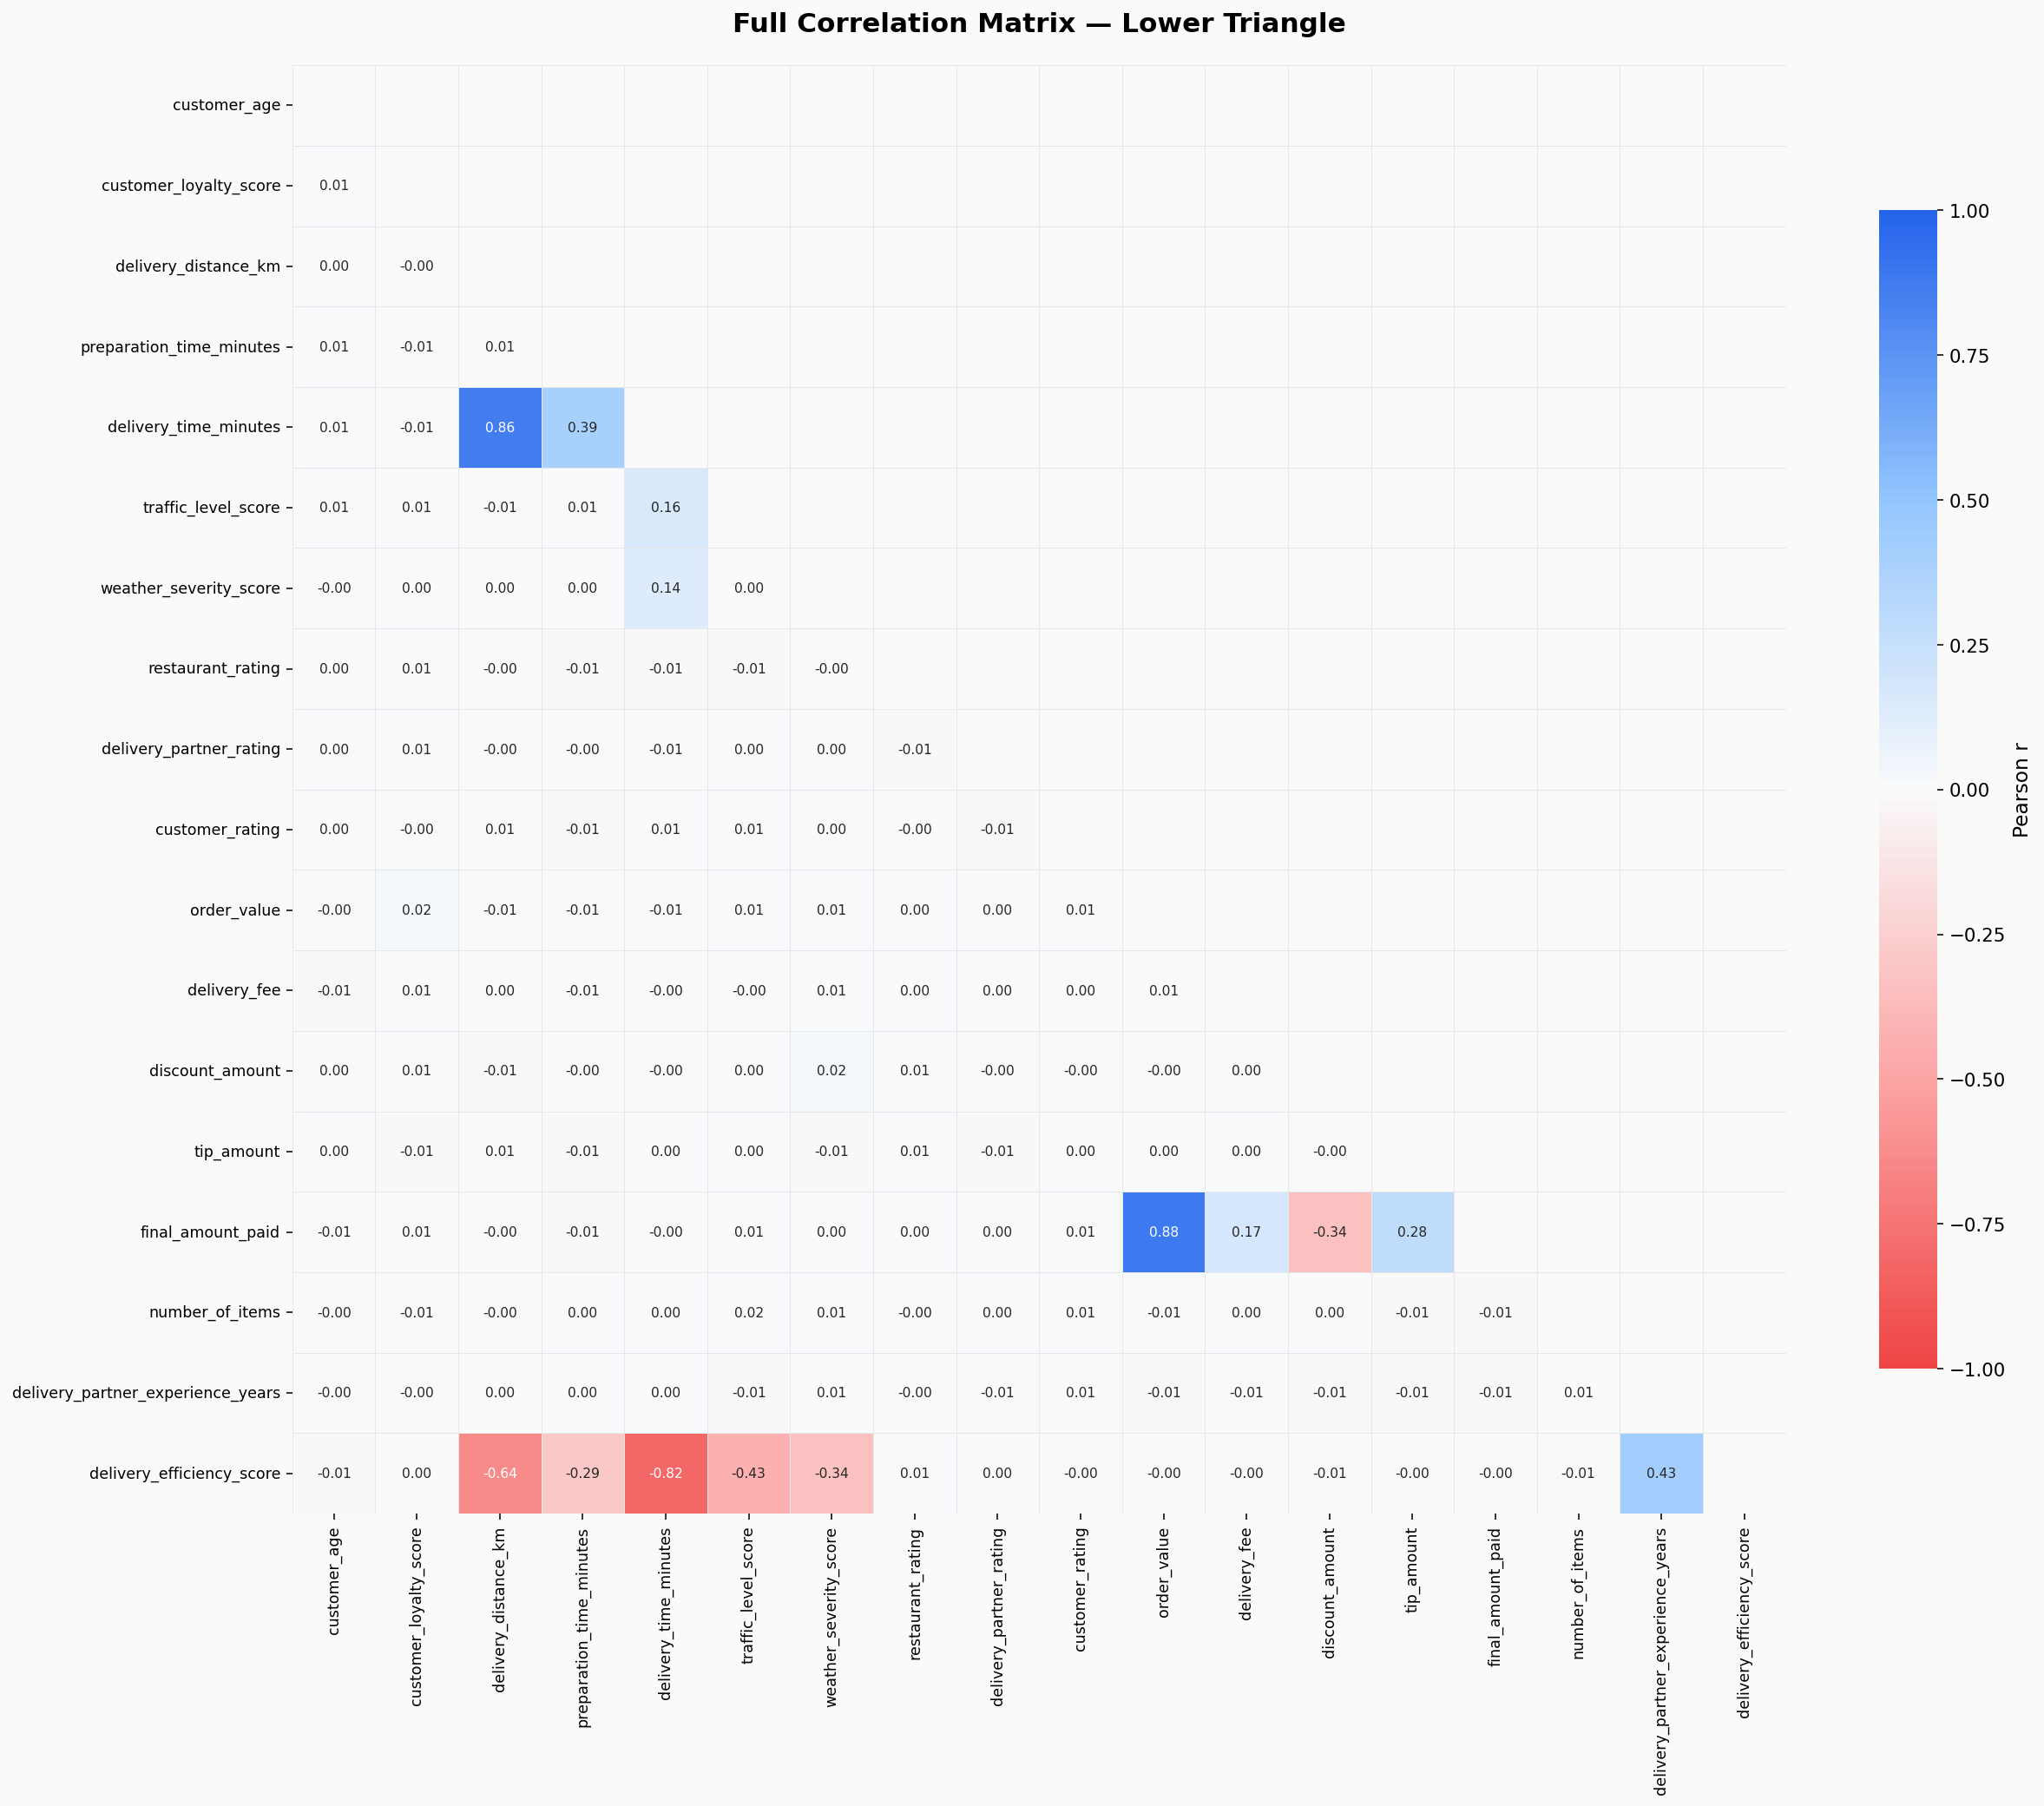

In [ ]:
numeric_cols = ["customer_age","customer_loyalty_score","delivery_distance_km",
                "preparation_time_minutes","delivery_time_minutes","traffic_level_score",
                "weather_severity_score","restaurant_rating","delivery_partner_rating",
                "customer_rating","order_value","delivery_fee","discount_amount",
                "tip_amount","final_amount_paid","number_of_items",
                "delivery_partner_experience_years","delivery_efficiency_score"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
fig.patch.set_facecolor(BG)

# Custom diverging colormap
cmap = LinearSegmentedColormap.from_list("custom_div",
        ["#ef4444","#fca5a5","#f9fafb","#93c5fd","#2563eb"], N=256)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.4, linecolor="#e5e7eb",
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

ax.set_title("Full Correlation Matrix — Lower Triangle", fontsize=16, fontweight="bold", pad=20)
ax.tick_params(axis="x", rotation=45*2, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("correlation.png", bbox_inches="tight", dpi=150)
plt.show()

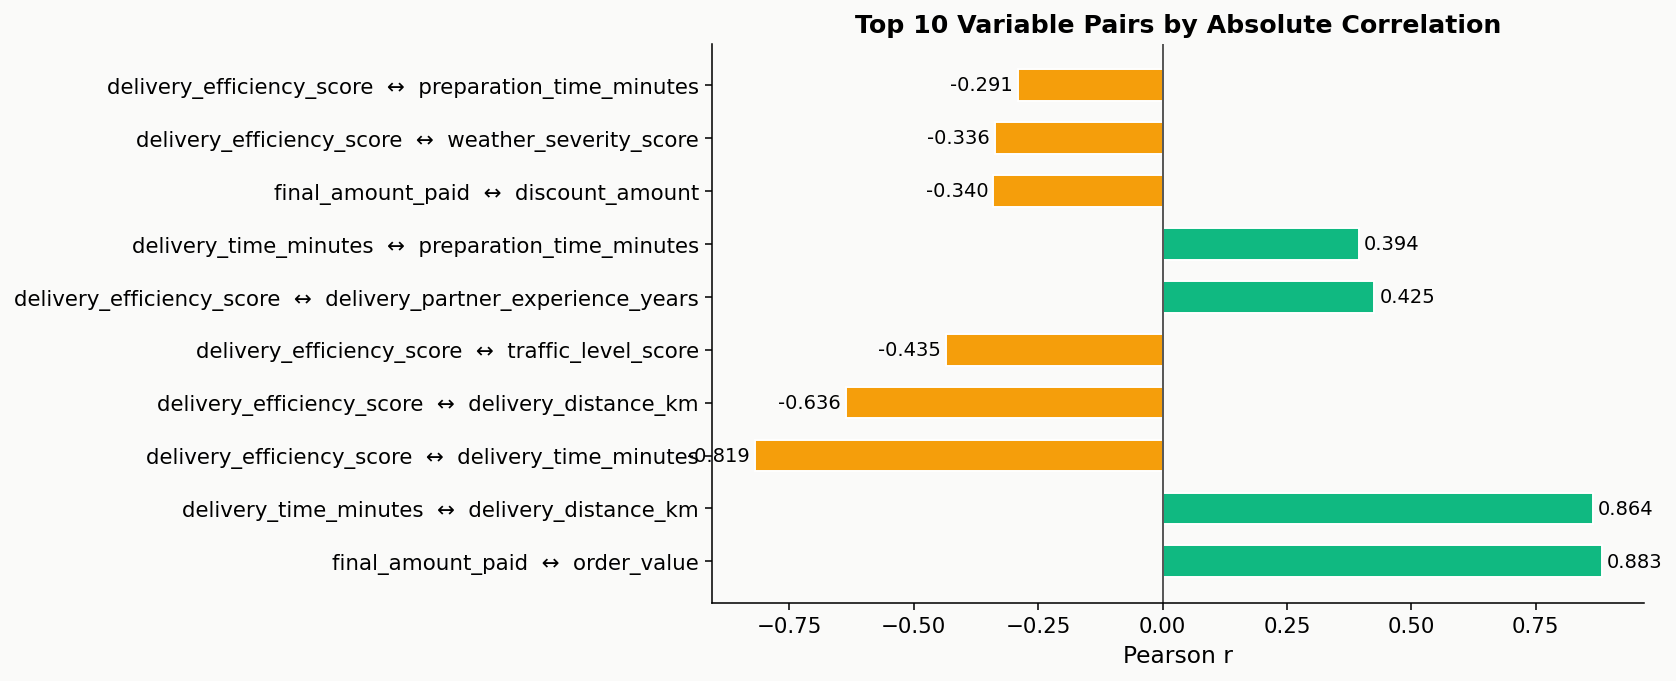

In [ ]:
# Top 10 correlation pairs (excluding self-correlation)
corr_pairs = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack()
              .reset_index()
              .rename(columns={0:"correlation", "level_0":"var1", "level_1":"var2"}))

corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
top10 = corr_pairs.sort_values("abs_corr", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
bar_colors = [PALETTE[2] if c > 0 else PALETTE[3] for c in top10["correlation"]]
bars = ax.barh([f"{r.var1}  ↔  {r.var2}" for _, r in top10.iterrows()],
               top10["correlation"], color=bar_colors, edgecolor="white", height=0.6)
ax.axvline(0, color="#555", linewidth=1)
ax.set_title("Top 10 Variable Pairs by Absolute Correlation", fontweight="bold", fontsize=13)
ax.set_xlabel("Pearson r")
for bar, val in zip(bars, top10["correlation"]):
    ax.text(val + (0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val>=0 else "right", fontsize=10)
plt.tight_layout()
plt.savefig("top_corr.png", bbox_inches="tight", dpi=150)
plt.show()

<a id='14'></a>

---

## 14 — Key Takeaways

<div style="background: linear-gradient(135deg, #faf5ff 0%, #ede9fe 100%); padding: 30px 40px; border-radius: 16px; border-left: 5px solid #7c3aed; font-family: Georgia, serif; line-height: 1.9;">

**Distance is destiny.** With a correlation of 0.86 against delivery time, the single most powerful predictor of how fast a meal arrives is the gap between kitchen and door.

**Experience is a compounding asset.** Partner efficiency scores climb monotonically from 46.7 at Year 1 to 71.6 at Year 15 — a 53% performance improvement that cannot be replicated by technology alone.

**Premium customers pay more, tip marginally more, but do not receive meaningfully faster service** — an opportunity for SLA differentiation.

**Severe weather costs 12–15 extra delivery minutes on average**, and the delay rate spikes noticeably at the extreme end of the weather severity scale.

**The operational funnel loses ~23% of orders** to cancellations, delays, and refunds combined — with cancellations alone accounting for ~13.4%.

**Customer ratings cluster tightly around 4.0** across virtually every segment, suggesting a rating inflation phenomenon rather than true satisfaction measurement.

**Loyalty tiers show minimal spending differentiation** — loyalty programmes may need redesign to drive genuine spend uplift.

</div>

---

<div style="text-align:center; padding: 30px; color: #7c3aed; font-family: Georgia; font-size: 1rem; letter-spacing: 2px;">
END OF NOTEBOOK — THE UNIVERSE EXPLORED
</div>